# Final Blind ROME Detection Analysis

This notebook implements an end-to-end, blind evaluation pipeline for ROME edit detection and edited-layer localization.

## Objectives

1. Detect whether a model appears ROME-edited from structural signals (blind inference).
2. Predict which layer was edited.
3. Compare multiple robust approaches and keep only the top 3.
4. Use baseline (unedited) references in evaluation to measure false positives.

## Constraints Applied

- Inference logic is blind: no original model access at runtime.
- Baseline references are used only for evaluation/calibration checks.
- Avoid brittle fixed constants; prefer rank/quantile/calibrated decisions.
- Visual preference: line graphs with baseline values clearly highlighted.


In [25]:
from __future__ import annotations

import json
import math
import re
import warnings
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
    from sklearn.model_selection import GroupKFold
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    SKLEARN_AVAILABLE = True
except Exception as e:
    SKLEARN_AVAILABLE = False
    SKLEARN_IMPORT_ERROR = e

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (15, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

ROOT = Path.cwd().resolve()
for p in [ROOT, *ROOT.parents]:
    if (p / "analysis_out").exists() and (p / "notebooks" / "new-gen").exists():
        ROOT = p
        break

ANALYSIS_DIR = ROOT / "analysis_out"
COMPLEX_DIR = ANALYSIS_DIR / "complex_analysis"
FINAL_NOTEBOOK = ROOT / "notebooks" / "new-gen" / "final_blind_detection_analysis.ipynb"

MODEL_FILTERS = {"gpt2-large", "gpt2-xl", "qwen3-4b"}
DETECTORS = ["blind", "spectral", "composite", "rank1_blind", "attention", "symmetry", "ipr", "presence"]
MAP_DETECTORS = ["blind", "spectral", "rank1_blind", "attention", "symmetry", "ipr"]

print(f"ROOT: {ROOT}")
print(f"Complex directory exists: {COMPLEX_DIR.exists()} -> {COMPLEX_DIR}")
print(f"Analysis directory exists: {ANALYSIS_DIR.exists()} -> {ANALYSIS_DIR}")
print(f"Sklearn available: {SKLEARN_AVAILABLE}")
if not SKLEARN_AVAILABLE:
    print(f"Sklearn import error: {SKLEARN_IMPORT_ERROR}")

ROOT: /data/olexa/Latium
Complex directory exists: True -> /data/olexa/Latium/analysis_out/complex_analysis
Analysis directory exists: True -> /data/olexa/Latium/analysis_out
Sklearn available: True


In [26]:
_MODEL_CANONICAL_MAP = {
    "qwen/qwen3-4b": "qwen3-4b",
    "qwen3-4b": "qwen3-4b",
    "gpt2-large": "gpt2-large",
    "gpt2-xl": "gpt2-xl",
}

_SWEEP_SLUG_RE = re.compile(
    r"tk(?P<top_k>\d+)"
    r"_tf(?P<trim_first>[^_]+)"
    r"_tl(?P<trim_last>[^_]+)"
    r"_nl(?P<neighbor_layers>\d+)"
    r"_rw(?P<rolling_window>\d+)"
    r"_lw(?P<local_windows>[^_]+)"
)

_FILENAME_SWEEP_RE = re.compile(
    r"_tk(?P<top_k>\d+)"
    r"_tf(?P<trim_first>[^_]+)"
    r"_tl(?P<trim_last>[^_]+)"
    r"_nl(?P<neighbor_layers>\d+)"
    r"_rw(?P<rolling_window>\d+)"
    r"_lw(?P<local_windows>[^_]+)"
)


def canonical_model_name(model: Any) -> str:
    raw = str(model or "unknown").strip()
    return _MODEL_CANONICAL_MAP.get(raw.lower(), raw)


def get_nested(obj: Any, path: Sequence[str], default: Any = None) -> Any:
    cur = obj
    for key in path:
        if not isinstance(cur, dict):
            return default
        cur = cur.get(key)
    return default if cur is None else cur


def coerce_int(x: Any) -> Optional[int]:
    try:
        return int(x)
    except Exception:
        return None


def coerce_float(x: Any, default: float = np.nan) -> float:
    try:
        return float(x)
    except Exception:
        return default


def coerce_optional_int_token(token: Any) -> Optional[int]:
    t = str(token).strip().lower()
    if t in {"auto", "none", "default", "nan"}:
        return None
    return coerce_int(t)


def coerce_layer_map(value: Any) -> Dict[int, float]:
    out: Dict[int, float] = {}
    if isinstance(value, dict):
        for k, v in value.items():
            lk = coerce_int(k)
            if lk is None:
                continue
            fv = coerce_float(v)
            if np.isfinite(fv):
                out[int(lk)] = float(fv)
        return out

    if isinstance(value, (list, tuple)):
        for i, v in enumerate(value):
            fv = coerce_float(v)
            if np.isfinite(fv):
                out[int(i)] = float(fv)
        return out

    if isinstance(value, np.ndarray):
        if value.ndim == 1:
            for i, v in enumerate(value.tolist()):
                fv = coerce_float(v)
                if np.isfinite(fv):
                    out[int(i)] = float(fv)
    return out


def rank01(vals: np.ndarray) -> np.ndarray:
    vals = np.asarray(vals, dtype=float)
    n = vals.size
    if n <= 1:
        return np.zeros(n, dtype=float)
    safe = np.where(np.isfinite(vals), vals, -np.inf)
    order = np.argsort(safe)
    ranks = np.empty(n, dtype=float)
    ranks[order] = np.arange(n, dtype=float)
    return ranks / max(1.0, float(n - 1))


def normalized_entropy(vals: np.ndarray) -> float:
    x = np.asarray(vals, dtype=float)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = np.clip(x, 0.0, None)
    if x.size <= 1:
        return 0.0
    s = x.sum()
    if s <= 0.0:
        return 1.0
    p = x / s
    ent = -np.sum(p * np.log(np.clip(p, 1e-12, 1.0)))
    return float(ent / np.log(x.size))


def robust_peak_z(vals: np.ndarray) -> float:
    x = np.asarray(vals, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 0.0
    med = float(np.median(x))
    mad = float(np.median(np.abs(x - med))) + 1e-12
    z = 0.6745 * (x.max() - med) / mad
    return float(max(0.0, z))


def parse_sweep_slug(sweep_slug: Any) -> Dict[str, Any]:
    out = {
        "spectral_top_k": None,
        "trim_first": None,
        "trim_last": None,
        "spectral_neighbor_layers": None,
        "spectral_rolling_window": None,
        "local_windows": None,
    }
    if not sweep_slug:
        return out
    m = _SWEEP_SLUG_RE.search(str(sweep_slug))
    if not m:
        return out
    out["spectral_top_k"] = coerce_optional_int_token(m.group("top_k"))
    out["trim_first"] = coerce_optional_int_token(m.group("trim_first"))
    out["trim_last"] = coerce_optional_int_token(m.group("trim_last"))
    out["spectral_neighbor_layers"] = coerce_optional_int_token(m.group("neighbor_layers"))
    out["spectral_rolling_window"] = coerce_optional_int_token(m.group("rolling_window"))
    out["local_windows"] = m.group("local_windows")
    return out


def parse_filename_sweep(path: Path) -> Dict[str, Any]:
    out = {
        "spectral_top_k": None,
        "trim_first": None,
        "trim_last": None,
        "spectral_neighbor_layers": None,
        "spectral_rolling_window": None,
        "local_windows": None,
    }
    m = _FILENAME_SWEEP_RE.search(path.name)
    if not m:
        return out
    out["spectral_top_k"] = coerce_optional_int_token(m.group("top_k"))
    out["trim_first"] = coerce_optional_int_token(m.group("trim_first"))
    out["trim_last"] = coerce_optional_int_token(m.group("trim_last"))
    out["spectral_neighbor_layers"] = coerce_optional_int_token(m.group("neighbor_layers"))
    out["spectral_rolling_window"] = coerce_optional_int_token(m.group("rolling_window"))
    out["local_windows"] = m.group("local_windows")
    return out


def merge_sweep_metadata(md: Dict[str, Any], path: Path) -> Dict[str, Any]:
    md = md or {}
    out = parse_filename_sweep(path)

    slug = md.get("sweep_slug")
    slug_parsed = parse_sweep_slug(slug)
    for k, v in slug_parsed.items():
        if v is not None:
            out[k] = v

    spectral_cfg = md.get("spectral_config", {}) or {}
    out["spectral_top_k"] = out["spectral_top_k"] or coerce_int(spectral_cfg.get("top_k"))
    out["trim_first"] = out["trim_first"] if out["trim_first"] is not None else coerce_int(spectral_cfg.get("trim_first"))
    out["trim_last"] = out["trim_last"] if out["trim_last"] is not None else coerce_int(spectral_cfg.get("trim_last"))
    out["spectral_neighbor_layers"] = out["spectral_neighbor_layers"] or coerce_int(spectral_cfg.get("neighbor_layers"))
    out["spectral_rolling_window"] = out["spectral_rolling_window"] or coerce_int(spectral_cfg.get("rolling_window"))

    analytics_cfg = md.get("analytics_config", {}) or {}
    lw = analytics_cfg.get("local_windows")
    if out["local_windows"] is None and isinstance(lw, (list, tuple)) and len(lw) > 0:
        out["local_windows"] = "-".join(str(int(v)) for v in lw)

    return out

In [27]:
DETECTOR_SPECS: Dict[str, Dict[str, Any]] = {
    "blind": {
        "case_path": ("blind_detection",),
        "baseline_path": ("baseline_blind",),
        "pred_keys": ("anomalous_layer",),
        "score_keys": ("detection_score", "layer_anomaly_score", "anomaly_score"),
        "map_pref": ("layer_anomaly_score", "isolation_scores", "combined_score"),
    },
    "spectral": {
        "case_path": ("spectral_detection",),
        "baseline_path": ("baseline_spectral",),
        "pred_keys": ("anomalous_layer",),
        "score_keys": ("detection_score", "anomaly_score"),
        "map_pref": (
            "rome_hybrid_scores",
            "sv_z_rolling_z_scores",
            "sv_ratio_rolling_z_scores",
            "sv_z_scores",
            "sv_ratio_scores",
            "combined_score",
        ),
    },
    "composite": {
        "case_path": ("composite_detection",),
        "baseline_path": ("baseline_composite",),
        "pred_keys": ("anomalous_layer",),
        "score_keys": ("detection_score", "spectral_diff_z", "spectral_hybrid_z"),
        "map_pref": ("combined_score", "layer_score_map"),
    },
    "rank1_blind": {
        "case_path": ("rank1_blind_detection",),
        "baseline_path": ("baseline_rank1_blind",),
        "pred_keys": ("anomalous_layer",),
        "score_keys": ("detection_score", "anomaly_score"),
        "map_pref": (
            "combined_score",
            "raw_rank_score",
            "proj_series.top1_energy",
            "proj_series.gap12",
        ),
    },
    "attention": {
        "case_path": ("attention_detection",),
        "baseline_path": ("baseline_attention",),
        "pred_keys": ("anomalous_layer",),
        "score_keys": ("detection_score", "anomaly_score"),
        "map_pref": ("combined_score", "attention_contrast_series"),
    },
    "symmetry": {
        "case_path": ("symmetry_detection",),
        "baseline_path": ("baseline_symmetry",),
        "pred_keys": ("anomalous_layer",),
        "score_keys": ("detection_score", "anomaly_score"),
        "map_pref": ("combined_score", "symmetry_anomaly_series"),
    },
    "ipr": {
        "case_path": ("ipr", "detection"),
        "baseline_path": ("baseline_ipr", "detection"),
        "pred_keys": ("anomalous_layer",),
        "score_keys": ("detection_score", "anomaly_score"),
        "map_pref": ("combined_score", "layer_scores"),
    },
    "presence": {
        "case_path": ("edit_presence_detection",),
        "baseline_path": ("baseline_edit_presence",),
        "pred_keys": ("peak_layer", "anomalous_layer"),
        "score_keys": ("confidence", "score"),
        "map_pref": ("combined_score", "raw_rank_score"),
    },
}


def iter_complex_files() -> List[Path]:
    files = sorted(COMPLEX_DIR.glob("rome_structural_*.json"))
    files = [p for p in files if canonical_model_name(p.name.split("rome_structural_")[-1].split("_tk")[0]) in MODEL_FILTERS or any(m in p.name.lower() for m in MODEL_FILTERS)]
    return files


def iter_baseline_reference_files(max_files: Optional[int] = None) -> List[Path]:
    files = sorted(ANALYSIS_DIR.glob("rome_structural_*.json"))
    files = [p for p in files if "complex_analysis" not in str(p)]
    files = [p for p in files if any(m in p.name.lower() for m in MODEL_FILTERS)]

    out: List[Path] = []
    for p in files:
        try:
            with p.open("r", encoding="utf-8") as f:
                head = f.read(50000)
            if "\"baseline_" in head:
                out.append(p)
        except Exception:
            continue

    if max_files is not None:
        out = out[: max(1, int(max_files))]
    return out


def collect_numeric_layer_maps(obj: Any, prefix: Tuple[str, ...] = (), max_depth: int = 4) -> List[Tuple[str, Dict[int, float]]]:
    if max_depth < 0:
        return []

    found: List[Tuple[str, Dict[int, float]]] = []
    direct = coerce_layer_map(obj)
    if len(direct) >= 4:
        found.append((".".join(prefix) if prefix else "<root>", direct))

    if isinstance(obj, dict):
        for k, v in obj.items():
            if isinstance(v, (dict, list, tuple)):
                found.extend(collect_numeric_layer_maps(v, prefix=(*prefix, str(k)), max_depth=max_depth - 1))
    elif isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            if isinstance(v, (dict, list, tuple)):
                found.extend(collect_numeric_layer_maps(v, prefix=(*prefix, str(i)), max_depth=max_depth - 1))

    dedup: Dict[str, Dict[int, float]] = {}
    for name, layer_map in found:
        if name not in dedup or len(layer_map) > len(dedup[name]):
            dedup[name] = layer_map
    return [(k, v) for k, v in dedup.items()]


def choose_layer_map(candidates: List[Tuple[str, Dict[int, float]]], preferences: Sequence[str]) -> Tuple[Optional[str], Dict[int, float]]:
    if not candidates:
        return None, {}

    lower_candidates = [(name.lower(), name, layer_map) for name, layer_map in candidates]
    for pref in preferences:
        token = str(pref).lower()
        for low_name, real_name, layer_map in lower_candidates:
            if token in low_name:
                return real_name, layer_map

    best = sorted(candidates, key=lambda x: len(x[1]), reverse=True)[0]
    return best[0], best[1]


def extract_pred_score(block: Dict[str, Any], detector: str) -> Tuple[Optional[int], float]:
    spec = DETECTOR_SPECS[detector]

    pred = None
    for key in spec["pred_keys"]:
        pred = coerce_int(block.get(key))
        if pred is not None:
            break

    score = np.nan
    for key in spec["score_keys"]:
        score = coerce_float(block.get(key))
        if np.isfinite(score):
            break

    if detector == "presence" and not np.isfinite(score):
        score = coerce_float(block.get("confidence"))

    return pred, score


def extract_rank1_diff_map(block: Dict[str, Any]) -> Dict[int, float]:
    contrast = get_nested(block, ("contrast_series",), default={})
    if not isinstance(contrast, dict):
        return {}

    maps: List[Dict[int, float]] = []
    for key, value in contrast.items():
        if "gap" not in str(key):
            continue
        layer_map = coerce_layer_map(value)
        if len(layer_map) >= 4:
            maps.append(layer_map)

    if not maps:
        return {}

    layers = sorted(set().union(*[m.keys() for m in maps]))
    stack = []
    for m in maps:
        arr = np.array([m.get(l, np.nan) for l in layers], dtype=float)
        arr = np.nan_to_num(arr, nan=np.nanmedian(arr[np.isfinite(arr)]) if np.isfinite(arr).any() else 0.0)
        stack.append(rank01(arr))
    agg = np.nanmean(np.stack(stack), axis=0)
    return {int(l): float(agg[i]) for i, l in enumerate(layers)}


def extract_spectral_ratio_map(block: Dict[str, Any]) -> Dict[int, float]:
    for path in [("sv_ratio_rolling_z_scores",), ("sv_ratio_scores",)]:
        lm = coerce_layer_map(get_nested(block, path, default={}))
        if len(lm) >= 4:
            return lm
    return {}


def build_run_meta(path: Path, payload: Dict[str, Any], source_kind: str) -> Dict[str, Any]:
    md = payload.get("metadata", {}) or {}
    model = canonical_model_name(md.get("model"))
    sweep = merge_sweep_metadata(md, path)

    return {
        "source_kind": source_kind,
        "run_file": path.name,
        "model": model,
        "target_layer": coerce_int(md.get("target_layer")),
        "num_layers": coerce_int(md.get("num_layers")),
        "n_tests": coerce_int(md.get("n_tests")),
        "timestamp": md.get("timestamp"),
        "sweep_slug": md.get("sweep_slug") or f"file::{path.stem}",
        **sweep,
    }


def parse_runs(complex_files: Sequence[Path], baseline_files: Sequence[Path]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    run_rows: List[Dict[str, Any]] = []
    sample_rows: List[Dict[str, Any]] = []
    pred_rows: List[Dict[str, Any]] = []
    map_rows: List[Dict[str, Any]] = []

    for path in complex_files:
        payload = json.loads(path.read_text(encoding="utf-8"))
        run_meta = build_run_meta(path, payload, source_kind="edited")
        run_rows.append(run_meta)

        tests = payload.get("tests", [])
        for case in tests:
            if case.get("skipped") or case.get("error"):
                continue
            case_id = coerce_int(case.get("case_id"))
            if case_id is None:
                continue

            target = coerce_int(case.get("target_layer"))
            if target is None:
                target = run_meta["target_layer"]

            sample_id = f"edited::{path.name}::{case_id}"
            sample_rows.append({
                "sample_id": sample_id,
                "source_kind": "edited",
                "label_edited": 1,
                "run_file": path.name,
                "model": run_meta["model"],
                "case_id": case_id,
                "target_layer": target,
                "num_layers": run_meta["num_layers"],
                "spectral_top_k": run_meta["spectral_top_k"],
                "trim_first": run_meta["trim_first"],
                "trim_last": run_meta["trim_last"],
                "spectral_neighbor_layers": run_meta["spectral_neighbor_layers"],
                "spectral_rolling_window": run_meta["spectral_rolling_window"],
                "local_windows": run_meta["local_windows"],
                "sweep_slug": run_meta["sweep_slug"],
            })

            for detector in DETECTORS:
                spec = DETECTOR_SPECS[detector]
                block = get_nested(case, spec["case_path"], default={})
                if not isinstance(block, dict):
                    continue

                pred, score = extract_pred_score(block, detector)
                pred_rows.append({
                    "sample_id": sample_id,
                    "source_kind": "edited",
                    "label_edited": 1,
                    "run_file": path.name,
                    "model": run_meta["model"],
                    "case_id": case_id,
                    "target_layer": target,
                    "detector": detector,
                    "predicted_layer": pred,
                    "detection_score": score,
                })

                if detector in MAP_DETECTORS:
                    candidates = collect_numeric_layer_maps(block)
                    map_name, layer_map = choose_layer_map(candidates, spec["map_pref"])
                    for layer, value in layer_map.items():
                        map_rows.append({
                            "sample_id": sample_id,
                            "source_kind": "edited",
                            "label_edited": 1,
                            "run_file": path.name,
                            "model": run_meta["model"],
                            "case_id": case_id,
                            "target_layer": target,
                            "detector": detector,
                            "map_name": map_name,
                            "layer": int(layer),
                            "value": float(value),
                        })

                if detector == "rank1_blind":
                    rank1_diff = extract_rank1_diff_map(block)
                    for layer, value in rank1_diff.items():
                        map_rows.append({
                            "sample_id": sample_id,
                            "source_kind": "edited",
                            "label_edited": 1,
                            "run_file": path.name,
                            "model": run_meta["model"],
                            "case_id": case_id,
                            "target_layer": target,
                            "detector": "rank1_diff",
                            "map_name": "contrast_rank_fusion",
                            "layer": int(layer),
                            "value": float(value),
                        })

                if detector == "spectral":
                    ratio_map = extract_spectral_ratio_map(block)
                    for layer, value in ratio_map.items():
                        map_rows.append({
                            "sample_id": sample_id,
                            "source_kind": "edited",
                            "label_edited": 1,
                            "run_file": path.name,
                            "model": run_meta["model"],
                            "case_id": case_id,
                            "target_layer": target,
                            "detector": "spectral_ratio",
                            "map_name": "sv_ratio_map",
                            "layer": int(layer),
                            "value": float(value),
                        })

    for path in baseline_files:
        payload = json.loads(path.read_text(encoding="utf-8"))
        run_meta = build_run_meta(path, payload, source_kind="baseline_ref")
        run_rows.append(run_meta)

        sample_id = f"baseline::{path.name}"
        sample_rows.append({
            "sample_id": sample_id,
            "source_kind": "baseline_ref",
            "label_edited": 0,
            "run_file": path.name,
            "model": run_meta["model"],
            "case_id": -1,
            "target_layer": np.nan,
            "num_layers": run_meta["num_layers"],
            "spectral_top_k": run_meta["spectral_top_k"],
            "trim_first": run_meta["trim_first"],
            "trim_last": run_meta["trim_last"],
            "spectral_neighbor_layers": run_meta["spectral_neighbor_layers"],
            "spectral_rolling_window": run_meta["spectral_rolling_window"],
            "local_windows": run_meta["local_windows"],
            "sweep_slug": run_meta["sweep_slug"],
        })

        for detector in DETECTORS:
            spec = DETECTOR_SPECS[detector]
            block = get_nested(payload, spec["baseline_path"], default={})
            if not isinstance(block, dict):
                continue

            pred, score = extract_pred_score(block, detector)
            pred_rows.append({
                "sample_id": sample_id,
                "source_kind": "baseline_ref",
                "label_edited": 0,
                "run_file": path.name,
                "model": run_meta["model"],
                "case_id": -1,
                "target_layer": np.nan,
                "detector": detector,
                "predicted_layer": pred,
                "detection_score": score,
            })

            if detector in MAP_DETECTORS:
                candidates = collect_numeric_layer_maps(block)
                map_name, layer_map = choose_layer_map(candidates, spec["map_pref"])
                for layer, value in layer_map.items():
                    map_rows.append({
                        "sample_id": sample_id,
                        "source_kind": "baseline_ref",
                        "label_edited": 0,
                        "run_file": path.name,
                        "model": run_meta["model"],
                        "case_id": -1,
                        "target_layer": np.nan,
                        "detector": detector,
                        "map_name": map_name,
                        "layer": int(layer),
                        "value": float(value),
                    })

            if detector == "rank1_blind":
                rank1_diff = extract_rank1_diff_map(block)
                for layer, value in rank1_diff.items():
                    map_rows.append({
                        "sample_id": sample_id,
                        "source_kind": "baseline_ref",
                        "label_edited": 0,
                        "run_file": path.name,
                        "model": run_meta["model"],
                        "case_id": -1,
                        "target_layer": np.nan,
                        "detector": "rank1_diff",
                        "map_name": "contrast_rank_fusion",
                        "layer": int(layer),
                        "value": float(value),
                    })

            if detector == "spectral":
                ratio_map = extract_spectral_ratio_map(block)
                for layer, value in ratio_map.items():
                    map_rows.append({
                        "sample_id": sample_id,
                        "source_kind": "baseline_ref",
                        "label_edited": 0,
                        "run_file": path.name,
                        "model": run_meta["model"],
                        "case_id": -1,
                        "target_layer": np.nan,
                        "detector": "spectral_ratio",
                        "map_name": "sv_ratio_map",
                        "layer": int(layer),
                        "value": float(value),
                    })

    run_df = pd.DataFrame(run_rows)
    sample_df = pd.DataFrame(sample_rows).drop_duplicates(subset=["sample_id"]) if sample_rows else pd.DataFrame()
    pred_df = pd.DataFrame(pred_rows)
    map_df = pd.DataFrame(map_rows)

    if not pred_df.empty:
        pred_df["predicted_layer"] = pd.to_numeric(pred_df["predicted_layer"], errors="coerce")
        pred_df["detection_score"] = pd.to_numeric(pred_df["detection_score"], errors="coerce")
    if not map_df.empty:
        map_df["layer"] = pd.to_numeric(map_df["layer"], errors="coerce").astype("Int64")
        map_df["value"] = pd.to_numeric(map_df["value"], errors="coerce")

    return run_df, sample_df, pred_df, map_df


print("Parsing and extraction functions ready.")

Parsing and extraction functions ready.


In [28]:
complex_files = iter_complex_files()
baseline_files = iter_baseline_reference_files(max_files=None)

print(f"Complex files: {len(complex_files)}")
print(f"Baseline reference files: {len(baseline_files)}")

run_df, sample_df, pred_df, map_df = parse_runs(complex_files=complex_files, baseline_files=baseline_files)

print(f"run_df: {run_df.shape}")
print(f"sample_df: {sample_df.shape}")
print(f"pred_df: {pred_df.shape}")
print(f"map_df: {map_df.shape}")

if not run_df.empty:
    display(run_df.groupby(["source_kind", "model"]).size().rename("runs").reset_index())


complex_run_df = run_df[run_df["source_kind"] == "edited"].copy()
baseline_run_df = run_df[run_df["source_kind"] == "baseline_ref"].copy()


def _local_windows_distance(a: Any, b: Any) -> float:
    if pd.isna(a) and pd.isna(b):
        return 0.0
    if pd.isna(a) or pd.isna(b):
        return 1.0
    sa = set(str(a).split("-"))
    sb = set(str(b).split("-"))
    if not sa and not sb:
        return 0.0
    if not sa or not sb:
        return 1.0
    inter = len(sa.intersection(sb))
    union = len(sa.union(sb))
    return 1.0 - (inter / max(1, union))


def _param_distance(c_row: pd.Series, b_row: pd.Series) -> float:
    d = 0.0
    for col in ["spectral_top_k", "trim_first", "trim_last", "spectral_neighbor_layers", "spectral_rolling_window"]:
        c = c_row.get(col)
        b = b_row.get(col)
        if pd.isna(c) and pd.isna(b):
            continue
        if pd.isna(c) or pd.isna(b):
            d += 1.0
            continue
        d += abs(float(c) - float(b))
    d += 2.0 * _local_windows_distance(c_row.get("local_windows"), b_row.get("local_windows"))
    return float(d)


match_rows: List[Dict[str, Any]] = []
if not complex_run_df.empty and not baseline_run_df.empty:
    for _, c_row in complex_run_df.iterrows():
        cand = baseline_run_df[baseline_run_df["model"] == c_row["model"]].copy()
        if cand.empty:
            continue
        cand = cand.assign(param_distance=cand.apply(lambda r: _param_distance(c_row, r), axis=1))
        best = cand.sort_values(["param_distance", "run_file"]).iloc[0]
        match_rows.append({
            "run_file": c_row["run_file"],
            "model": c_row["model"],
            "matched_baseline_run_file": best["run_file"],
            "match_distance": best["param_distance"],
        })

run_match_df = pd.DataFrame(match_rows)
print(f"Run matches found: {len(run_match_df)}")
if not run_match_df.empty:
    display(run_match_df.head(12))

sample_df = sample_df.merge(run_match_df[["run_file", "matched_baseline_run_file", "match_distance"]], on="run_file", how="left")

Complex files: 24
Baseline reference files: 17


run_df: (41, 14)
sample_df: (2417, 15)
pred_df: (19336, 10)
map_df: (675972, 11)


,source_kind,model,runs
0,baseline_ref,gpt2-large,6
1,baseline_ref,gpt2-xl,6
2,baseline_ref,qwen3-4b,5
3,edited,gpt2-large,8
4,edited,gpt2-xl,8
5,edited,qwen3-4b,8


Run matches found: 24


,run_file,model,matched_baseline_run_file,match_distance
0,rome_structural_gpt2-large_tk16_tf2_tl2_nl1_rw...,gpt2-large,rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw...,34.0
1,rome_structural_gpt2-large_tk32_tf2_tl2_nl1_rw...,gpt2-large,rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw...,18.0
2,rome_structural_gpt2-large_tk48_tf2_tl2_nl1_rw...,gpt2-large,rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw...,2.0
3,rome_structural_gpt2-large_tk4_tf2_tl2_nl1_rw5...,gpt2-large,rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw...,46.0
4,rome_structural_gpt2-large_tk64_tf2_tl2_nl1_rw...,gpt2-large,rome_structural_gpt2-large_tk64_tf3_tl3_nl2_rw...,8.6
5,rome_structural_gpt2-large_tk6_tf2_tl2_nl1_rw5...,gpt2-large,rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw...,44.0
6,rome_structural_gpt2-large_tk8_tf2_tl2_nl1_rw5...,gpt2-large,rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw...,42.0
7,rome_structural_gpt2-large_tk96_tf2_tl2_nl1_rw...,gpt2-large,rome_structural_gpt2-large_tk64_tf3_tl3_nl2_rw...,40.6
8,rome_structural_gpt2-xl_tk16_tf2_tl2_nl1_rw5_l...,gpt2-xl,rome_structural_gpt2-xl_tk50_tf2_tl2_nl1_rw5_l...,34.0
9,rome_structural_gpt2-xl_tk32_tf2_tl2_nl1_rw5_l...,gpt2-xl,rome_structural_gpt2-xl_tk50_tf2_tl2_nl1_rw5_l...,18.0


In [29]:
def build_pred_lookup(pred_df: pd.DataFrame) -> Dict[str, Dict[str, Dict[str, float]]]:
    out: Dict[str, Dict[str, Dict[str, float]]] = {}
    for row in pred_df.itertuples(index=False):
        sid = str(row.sample_id)
        det = str(row.detector)
        out.setdefault(sid, {})[det] = {
            "predicted_layer": np.nan if pd.isna(row.predicted_layer) else float(row.predicted_layer),
            "detection_score": np.nan if pd.isna(row.detection_score) else float(row.detection_score),
        }
    return out


def build_map_lookup(map_df: pd.DataFrame) -> Dict[str, Dict[str, Dict[int, float]]]:
    out: Dict[str, Dict[str, Dict[int, float]]] = {}
    if map_df.empty:
        return out

    for (sid, det), sub in map_df.groupby(["sample_id", "detector"]):
        layer_map: Dict[int, float] = {}
        for layer, value in zip(sub["layer"].tolist(), sub["value"].tolist()):
            if pd.isna(layer) or pd.isna(value):
                continue
            layer_map[int(layer)] = float(value)
        if layer_map:
            out.setdefault(str(sid), {})[str(det)] = dict(sorted(layer_map.items()))
    return out


def _resolve_depth(sample_row: pd.Series, detector_maps: Dict[str, Dict[int, float]]) -> int:
    depth = coerce_int(sample_row.get("num_layers")) or 0
    if depth <= 0:
        max_layer = -1
        for m in detector_maps.values():
            if m:
                max_layer = max(max_layer, max(m.keys()))
        depth = max_layer + 1 if max_layer >= 0 else 1
    return max(1, depth)


def _top_margin(values: np.ndarray) -> Tuple[float, float]:
    if values.size == 0:
        return 0.0, 0.0
    v = np.sort(values)
    top = float(v[-1])
    second = float(v[-2]) if values.size > 1 else top
    return top, float(max(0.0, top - second))


def _rank01_map(layer_map: Dict[int, float]) -> Dict[int, float]:
    if not layer_map:
        return {}
    layers = sorted(layer_map.keys())
    arr = np.array([layer_map[l] for l in layers], dtype=float)
    ranks = rank01(arr)
    return {int(l): float(ranks[i]) for i, l in enumerate(layers)}


def fit_detector_weights(train_ids: Sequence[str], sample_df: pd.DataFrame, pred_df: pd.DataFrame, detectors: Sequence[str]) -> Dict[str, float]:
    sub = pred_df[pred_df["sample_id"].isin(train_ids)].copy()
    sub = sub[sub["detector"].isin(detectors)]

    # pred_df already carries label_edited/target_layer for this pipeline.
    # Merge sample metadata only as a fallback to avoid suffix collisions.
    if "label_edited" not in sub.columns or "target_layer" not in sub.columns:
        edited_meta = sample_df[["sample_id", "target_layer", "label_edited"]].copy()
        sub = sub.merge(edited_meta, on="sample_id", how="left", suffixes=("", "_meta"))
        if "label_edited_meta" in sub.columns and "label_edited" not in sub.columns:
            sub["label_edited"] = sub["label_edited_meta"]
        if "target_layer_meta" in sub.columns and "target_layer" not in sub.columns:
            sub["target_layer"] = sub["target_layer_meta"]

    sub["label_edited"] = pd.to_numeric(sub["label_edited"], errors="coerce")
    sub["target_layer"] = pd.to_numeric(sub["target_layer"], errors="coerce")
    sub["predicted_layer"] = pd.to_numeric(sub["predicted_layer"], errors="coerce")
    sub = sub[(sub["label_edited"] == 1) & sub["target_layer"].notna() & sub["predicted_layer"].notna()]

    raw: Dict[str, float] = {d: 0.0 for d in detectors}
    if sub.empty:
        return {d: 1.0 / max(1, len(detectors)) for d in detectors}

    for det in detectors:
        dsub = sub[sub["detector"] == det].copy()
        if dsub.empty:
            continue
        dsub["abs_err"] = (dsub["predicted_layer"] - dsub["target_layer"]).abs()
        exact = float((dsub["abs_err"] == 0).mean())
        hit1 = float((dsub["abs_err"] <= 1).mean())
        score_std = float(pd.to_numeric(dsub["detection_score"], errors="coerce").std())
        score_std = score_std if np.isfinite(score_std) and score_std > 0 else 1.0
        raw[det] = (0.65 * exact + 0.35 * hit1) / score_std

    s = sum(raw.values())
    if s <= 0:
        return {d: 1.0 / max(1, len(detectors)) for d in detectors}
    return {d: float(raw[d] / s) for d in detectors}


def infer_rank_fusion(sample_row: pd.Series, det_maps: Dict[str, Dict[int, float]], detectors: Sequence[str], agg: str = "median") -> Dict[str, Any]:
    depth = _resolve_depth(sample_row, det_maps)
    layers = np.arange(depth, dtype=int)

    curves: List[np.ndarray] = []
    used: List[str] = []
    for det in detectors:
        lm = det_maps.get(det, {})
        if not lm:
            continue
        ranked = _rank01_map(lm)
        curves.append(np.array([ranked.get(int(l), 0.0) for l in layers], dtype=float))
        used.append(det)

    if curves:
        stack = np.stack(curves)
        if agg == "trimmed" and stack.shape[0] >= 3:
            low_drop = int(math.floor(stack.shape[0] * 0.25))
            sorted_stack = np.sort(stack, axis=0)
            fused = sorted_stack[low_drop:, :].mean(axis=0)
        elif agg == "mean":
            fused = stack.mean(axis=0)
        else:
            fused = np.median(stack, axis=0)
    else:
        fused = np.zeros(depth, dtype=float)

    pred_layer = int(layers[int(np.argmax(fused))]) if fused.size else None
    top, margin = _top_margin(fused)
    entropy = normalized_entropy(fused)
    peak_z = robust_peak_z(fused)

    return {
        "pred_layer": pred_layer,
        "edited_score": float(0.45 * top + 0.30 * margin + 0.15 * (1.0 - entropy) + 0.10 * np.tanh(peak_z / 4.0)),
        "margin": float(margin),
        "entropy": float(entropy),
        "peak_z": float(peak_z),
        "support": int(len(used)),
        "layer_scores": {int(l): float(fused[i]) for i, l in enumerate(layers)},
        "used_detectors": used,
    }


def infer_calibrated_ensemble(sample_row: pd.Series, pred_item: Dict[str, Dict[str, float]], detector_weights: Dict[str, float], detectors: Sequence[str], depth_hint: int) -> Dict[str, Any]:
    depth = max(1, int(depth_hint))
    layers = np.arange(depth, dtype=int)
    fused = np.zeros(depth, dtype=float)
    used: List[str] = []

    scores = [pred_item.get(d, {}).get("detection_score", np.nan) for d in detectors]
    valid_scores = np.array([s for s in scores if np.isfinite(s)], dtype=float)
    if valid_scores.size > 0:
        order = np.argsort(valid_scores)
        ref = np.empty_like(valid_scores)
        ref[order] = np.arange(valid_scores.size, dtype=float)
        ref = ref / max(1.0, valid_scores.size - 1)
    else:
        ref = np.array([], dtype=float)

    score_iter = 0
    for det in detectors:
        p = pred_item.get(det, {})
        pl = p.get("predicted_layer", np.nan)
        if not np.isfinite(pl):
            continue
        if valid_scores.size > 0 and score_iter < ref.size:
            amp = float(ref[score_iter])
            score_iter += 1
        else:
            amp = 0.5

        sigma = max(1.0, depth * 0.04)
        bump = amp * np.exp(-0.5 * ((layers - float(pl)) / sigma) ** 2)
        fused += float(detector_weights.get(det, 0.0)) * bump
        used.append(det)

    pred_layer = int(layers[int(np.argmax(fused))]) if fused.size and used else None
    top, margin = _top_margin(fused)
    entropy = normalized_entropy(fused)
    peak_z = robust_peak_z(fused)

    return {
        "pred_layer": pred_layer,
        "edited_score": float(0.50 * top + 0.30 * margin + 0.10 * (1.0 - entropy) + 0.10 * np.tanh(peak_z / 4.0)),
        "margin": float(margin),
        "entropy": float(entropy),
        "peak_z": float(peak_z),
        "support": int(len(used)),
        "layer_scores": {int(l): float(fused[i]) for i, l in enumerate(layers)},
        "used_detectors": used,
    }


def infer_differential_consensus(sample_row: pd.Series, det_maps: Dict[str, Dict[int, float]]) -> Dict[str, Any]:
    depth = _resolve_depth(sample_row, det_maps)
    layers = np.arange(depth, dtype=int)

    preferred = ["rank1_diff", "spectral_ratio", "spectral", "rank1_blind"]
    curves: List[np.ndarray] = []
    used: List[str] = []
    for det in preferred:
        lm = det_maps.get(det, {})
        if not lm:
            continue
        ranked = _rank01_map(lm)
        curves.append(np.array([ranked.get(int(l), 0.0) for l in layers], dtype=float))
        used.append(det)

    if curves:
        fused = np.median(np.stack(curves), axis=0)
    else:
        fallback = infer_rank_fusion(sample_row, det_maps, ["spectral", "rank1_blind", "attention", "symmetry", "blind"], agg="trimmed")
        fallback["used_detectors"] = fallback["used_detectors"] + ["fallback"]
        return fallback

    pred_layer = int(layers[int(np.argmax(fused))]) if fused.size else None
    top, margin = _top_margin(fused)
    entropy = normalized_entropy(fused)
    peak_z = robust_peak_z(fused)

    return {
        "pred_layer": pred_layer,
        "edited_score": float(0.40 * top + 0.30 * margin + 0.20 * np.tanh(peak_z / 4.0) + 0.10 * (len(used) / max(1, len(preferred)))),
        "margin": float(margin),
        "entropy": float(entropy),
        "peak_z": float(peak_z),
        "support": int(len(used)),
        "layer_scores": {int(l): float(fused[i]) for i, l in enumerate(layers)},
        "used_detectors": used,
    }


def infer_single_detector(sample_row: pd.Series, det_maps: Dict[str, Dict[int, float]], detector: str) -> Dict[str, Any]:
    return infer_rank_fusion(sample_row, det_maps, [detector], agg="mean")


def run_strategy(
    strategy: str,
    train_ids: Sequence[str],
    test_ids: Sequence[str],
    sample_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    pred_lookup: Dict[str, Dict[str, Dict[str, float]]],
    map_lookup: Dict[str, Dict[str, Dict[int, float]]],
) -> pd.DataFrame:
    sample_index = sample_df.set_index("sample_id")

    common_detectors = ["blind", "spectral", "rank1_blind", "attention", "symmetry", "ipr"]
    detector_weights = fit_detector_weights(train_ids, sample_df, pred_df, common_detectors)

    rows: List[Dict[str, Any]] = []
    for sid in test_ids:
        if sid not in sample_index.index:
            continue
        srow = sample_index.loc[sid]
        det_maps = map_lookup.get(sid, {})
        pred_item = pred_lookup.get(sid, {})
        depth_hint = _resolve_depth(srow, det_maps)

        if strategy == "rank_fusion_median":
            out = infer_rank_fusion(srow, det_maps, common_detectors, agg="median")
        elif strategy == "rank_fusion_trimmed":
            out = infer_rank_fusion(srow, det_maps, common_detectors, agg="trimmed")
        elif strategy == "calibrated_ensemble":
            out = infer_calibrated_ensemble(srow, pred_item, detector_weights, common_detectors, depth_hint=depth_hint)
        elif strategy == "differential_consensus":
            out = infer_differential_consensus(srow, det_maps)
        elif strategy == "spectral_only":
            out = infer_single_detector(srow, det_maps, detector="spectral")
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        rows.append({
            "sample_id": sid,
            "strategy": strategy,
            "model": srow["model"],
            "label_edited": int(srow["label_edited"]),
            "target_layer": srow["target_layer"],
            "pred_layer": out["pred_layer"],
            "edited_score": out["edited_score"],
            "margin": out["margin"],
            "entropy": out["entropy"],
            "peak_z": out["peak_z"],
            "support": out["support"],
            "layer_scores": out["layer_scores"],
            "used_detectors": ",".join(out["used_detectors"]),
        })

    return pd.DataFrame(rows)


STRATEGY_CANDIDATES = [
    "rank_fusion_median",
    "rank_fusion_trimmed",
    "calibrated_ensemble",
    "differential_consensus",
    "spectral_only",
]

print("Strategy inference utilities ready.")

Strategy inference utilities ready.


In [30]:
# Hotfix: pred_df already carries label_edited/target_layer, so avoid merge-induced suffix collisions.
def fit_detector_weights(train_ids: Sequence[str], sample_df: pd.DataFrame, pred_df: pd.DataFrame, detectors: Sequence[str]) -> Dict[str, float]:
    sub = pred_df[pred_df["sample_id"].isin(train_ids)].copy()
    sub = sub[sub["detector"].isin(detectors)]

    # Backfill from sample_df only if required columns are missing.
    if "label_edited" not in sub.columns or "target_layer" not in sub.columns:
        edited_meta = sample_df[["sample_id", "target_layer", "label_edited"]].copy()
        sub = sub.merge(edited_meta, on="sample_id", how="left", suffixes=("", "_meta"))
        if "label_edited_meta" in sub.columns and "label_edited" not in sub.columns:
            sub["label_edited"] = sub["label_edited_meta"]
        if "target_layer_meta" in sub.columns and "target_layer" not in sub.columns:
            sub["target_layer"] = sub["target_layer_meta"]

    sub["label_edited"] = pd.to_numeric(sub["label_edited"], errors="coerce")
    sub["target_layer"] = pd.to_numeric(sub["target_layer"], errors="coerce")
    sub["predicted_layer"] = pd.to_numeric(sub["predicted_layer"], errors="coerce")

    sub = sub[(sub["label_edited"] == 1) & sub["target_layer"].notna() & sub["predicted_layer"].notna()]

    raw: Dict[str, float] = {d: 0.0 for d in detectors}
    if sub.empty:
        return {d: 1.0 / max(1, len(detectors)) for d in detectors}

    for det in detectors:
        dsub = sub[sub["detector"] == det].copy()
        if dsub.empty:
            continue
        dsub["abs_err"] = (dsub["predicted_layer"] - dsub["target_layer"]).abs()
        exact = float((dsub["abs_err"] == 0).mean())
        hit1 = float((dsub["abs_err"] <= 1).mean())
        score_std = float(pd.to_numeric(dsub["detection_score"], errors="coerce").std())
        score_std = score_std if np.isfinite(score_std) and score_std > 0 else 1.0
        raw[det] = (0.65 * exact + 0.35 * hit1) / score_std

    s = sum(raw.values())
    if s <= 0:
        return {d: 1.0 / max(1, len(detectors)) for d in detectors}
    return {d: float(raw[d] / s) for d in detectors}

print("Applied fit_detector_weights hotfix.")

Applied fit_detector_weights hotfix.


In [31]:
def fit_binary_calibrator(train_out: pd.DataFrame):
    feature_cols = ["edited_score", "margin", "peak_z", "support", "entropy"]
    train = train_out.copy()
    for c in feature_cols:
        train[c] = pd.to_numeric(train[c], errors="coerce").fillna(0.0)

    y = train["label_edited"].to_numpy(dtype=int)
    X = train[feature_cols].to_numpy(dtype=float)

    if SKLEARN_AVAILABLE and len(np.unique(y)) >= 2 and X.shape[0] >= 20:
        model = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
            ]
        )
        model.fit(X, y)
        train_prob = model.predict_proba(X)[:, 1]

        fpr, tpr, thr = roc_curve(y, train_prob)
        j = tpr - fpr
        best_idx = int(np.argmax(j))
        threshold = float(thr[best_idx])

        def _predict_prob(df: pd.DataFrame) -> np.ndarray:
            tmp = df.copy()
            for c in feature_cols:
                tmp[c] = pd.to_numeric(tmp[c], errors="coerce").fillna(0.0)
            return model.predict_proba(tmp[feature_cols].to_numpy(dtype=float))[:, 1]

        return _predict_prob, threshold

    # Fallback: use edited_score directly and calibrate threshold from baseline quantile.
    baseline_scores = train.loc[train["label_edited"] == 0, "edited_score"].to_numpy(dtype=float)
    baseline_scores = baseline_scores[np.isfinite(baseline_scores)]
    if baseline_scores.size == 0:
        threshold = float(np.nanmedian(train["edited_score"]))
    else:
        threshold = float(np.quantile(baseline_scores, 0.95))

    def _predict_prob(df: pd.DataFrame) -> np.ndarray:
        scores = pd.to_numeric(df["edited_score"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        med = float(np.median(scores)) if scores.size else 0.0
        mad = float(np.median(np.abs(scores - med))) + 1e-8
        z = (scores - med) / mad
        return 1.0 / (1.0 + np.exp(-z))

    return _predict_prob, threshold


def evaluate_outputs(train_out: pd.DataFrame, test_out: pd.DataFrame) -> Tuple[Dict[str, Any], pd.DataFrame]:
    if train_out.empty or test_out.empty:
        return {}, pd.DataFrame()

    predict_prob, threshold = fit_binary_calibrator(train_out)
    out = test_out.copy()
    out["p_edited"] = predict_prob(out)
    out["pred_edited"] = (out["p_edited"] >= threshold).astype(int)

    metrics: Dict[str, Any] = {
        "threshold": float(threshold),
        "n_test": int(out.shape[0]),
        "n_test_edited": int((out["label_edited"] == 1).sum()),
        "n_test_unedited": int((out["label_edited"] == 0).sum()),
    }

    base = out[out["label_edited"] == 0]
    edited = out[out["label_edited"] == 1]
    metrics["baseline_fpr"] = float((base["pred_edited"] == 1).mean()) if not base.empty else np.nan
    metrics["edited_tpr"] = float((edited["pred_edited"] == 1).mean()) if not edited.empty else np.nan

    y_true = out["label_edited"].to_numpy(dtype=int)
    y_prob = out["p_edited"].to_numpy(dtype=float)
    if len(np.unique(y_true)) >= 2:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
        metrics["pr_auc"] = float(average_precision_score(y_true, y_prob))
    else:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan

    loc = edited[edited["target_layer"].notna() & edited["pred_layer"].notna()].copy()
    if loc.empty:
        metrics["exact"] = np.nan
        metrics["hit_at_1"] = np.nan
        metrics["hit_at_2"] = np.nan
        metrics["mae"] = np.nan
    else:
        loc["abs_err"] = (loc["pred_layer"] - loc["target_layer"]).abs()
        metrics["exact"] = float((loc["abs_err"] == 0).mean())
        metrics["hit_at_1"] = float((loc["abs_err"] <= 1).mean())
        metrics["hit_at_2"] = float((loc["abs_err"] <= 2).mean())
        metrics["mae"] = float(loc["abs_err"].mean())

    return metrics, out


def make_lomo_folds(sample_df: pd.DataFrame) -> List[Dict[str, Any]]:
    folds: List[Dict[str, Any]] = []
    for model in sorted(sample_df["model"].dropna().unique()):
        test_ids = sample_df[sample_df["model"] == model]["sample_id"].tolist()
        train_ids = sample_df[sample_df["model"] != model]["sample_id"].tolist()
        if train_ids and test_ids:
            folds.append({"protocol": "lomo", "fold_id": f"holdout_{model}", "train_ids": train_ids, "test_ids": test_ids})
    return folds


def make_cross_sweep_folds(sample_df: pd.DataFrame) -> List[Dict[str, Any]]:
    folds: List[Dict[str, Any]] = []
    edited = sample_df[sample_df["label_edited"] == 1].copy()

    for model in sorted(edited["model"].dropna().unique()):
        e_sub = edited[edited["model"] == model].copy()
        topks = sorted([int(v) for v in e_sub["spectral_top_k"].dropna().unique()])
        if len(topks) < 2:
            continue

        group_a = set(topks[::2])
        group_b = set(topks[1::2])
        groups = [("A", group_a), ("B", group_b)]

        b_sub = sample_df[(sample_df["label_edited"] == 0) & (sample_df["model"] == model)].copy()

        for gid, gset in groups:
            if not gset:
                continue

            e_test_ids = e_sub[e_sub["spectral_top_k"].isin(gset)]["sample_id"].tolist()
            e_train_ids = e_sub[~e_sub["spectral_top_k"].isin(gset)]["sample_id"].tolist()
            if not e_test_ids or not e_train_ids:
                continue

            b_test_ids = b_sub[b_sub["spectral_top_k"].isin(gset)]["sample_id"].tolist()
            b_train_ids = b_sub[~b_sub["spectral_top_k"].isin(gset)]["sample_id"].tolist()

            if not b_test_ids and not b_sub.empty:
                b_test_ids = b_sub.sample(frac=0.5, random_state=13 + len(folds))["sample_id"].tolist()
                b_train_ids = b_sub[~b_sub["sample_id"].isin(b_test_ids)]["sample_id"].tolist()
            if not b_train_ids:
                b_train_ids = b_sub["sample_id"].tolist()

            folds.append({
                "protocol": "cross_sweep",
                "fold_id": f"{model}_group_{gid}",
                "train_ids": e_train_ids + b_train_ids,
                "test_ids": e_test_ids + b_test_ids,
            })

    return folds


def evaluate_protocol(
    folds: Sequence[Dict[str, Any]],
    strategies: Sequence[str],
    sample_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    pred_lookup: Dict[str, Dict[str, Dict[str, float]]],
    map_lookup: Dict[str, Dict[str, Dict[int, float]]],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    metric_rows: List[Dict[str, Any]] = []
    out_rows: List[pd.DataFrame] = []

    for fold in folds:
        for strategy in strategies:
            train_out = run_strategy(
                strategy=strategy,
                train_ids=fold["train_ids"],
                test_ids=fold["train_ids"],
                sample_df=sample_df,
                pred_df=pred_df,
                pred_lookup=pred_lookup,
                map_lookup=map_lookup,
            )
            test_out = run_strategy(
                strategy=strategy,
                train_ids=fold["train_ids"],
                test_ids=fold["test_ids"],
                sample_df=sample_df,
                pred_df=pred_df,
                pred_lookup=pred_lookup,
                map_lookup=map_lookup,
            )

            metrics, pred_out = evaluate_outputs(train_out, test_out)
            if not metrics:
                continue

            metrics["protocol"] = fold["protocol"]
            metrics["fold_id"] = fold["fold_id"]
            metrics["strategy"] = strategy
            metric_rows.append(metrics)

            if not pred_out.empty:
                pred_out = pred_out.copy()
                pred_out["protocol"] = fold["protocol"]
                pred_out["fold_id"] = fold["fold_id"]
                out_rows.append(pred_out)

    metrics_df = pd.DataFrame(metric_rows)
    pred_out_df = pd.concat(out_rows, ignore_index=True) if out_rows else pd.DataFrame()
    return metrics_df, pred_out_df


print("Evaluation utilities ready.")

Evaluation utilities ready.


In [32]:
# Patch: avoid merge-suffix issues by mapping labels/targets from sample metadata.
def fit_detector_weights(train_ids: Sequence[str], sample_df: pd.DataFrame, pred_df: pd.DataFrame, detectors: Sequence[str]) -> Dict[str, float]:
    sub = pred_df[pred_df["sample_id"].isin(train_ids)].copy()
    sub = sub[sub["detector"].isin(detectors)]

    meta = sample_df.drop_duplicates(subset=["sample_id"])[["sample_id", "target_layer", "label_edited"]].set_index("sample_id")
    sub["target_layer"] = sub["sample_id"].map(meta["target_layer"])
    sub["label_edited"] = sub["sample_id"].map(meta["label_edited"])

    sub = sub[(sub["label_edited"] == 1) & sub["target_layer"].notna() & sub["predicted_layer"].notna()]

    raw: Dict[str, float] = {d: 0.0 for d in detectors}
    if sub.empty:
        return {d: 1.0 / max(1, len(detectors)) for d in detectors}

    for det in detectors:
        dsub = sub[sub["detector"] == det].copy()
        if dsub.empty:
            continue
        dsub["abs_err"] = (dsub["predicted_layer"] - dsub["target_layer"]).abs()
        exact = float((dsub["abs_err"] == 0).mean())
        hit1 = float((dsub["abs_err"] <= 1).mean())
        score_std = float(pd.to_numeric(dsub["detection_score"], errors="coerce").std())
        score_std = score_std if np.isfinite(score_std) and score_std > 0 else 1.0
        raw[det] = (0.65 * exact + 0.35 * hit1) / score_std

    s = sum(raw.values())
    if s <= 0:
        return {d: 1.0 / max(1, len(detectors)) for d in detectors}
    return {d: float(raw[d] / s) for d in detectors}

print("Patched fit_detector_weights loaded.")

Patched fit_detector_weights loaded.


In [33]:
pred_lookup = build_pred_lookup(pred_df)
map_lookup = build_map_lookup(map_df)

print(f"Unique samples: {sample_df['sample_id'].nunique()}")
print(f"Lookup coverage (pred): {len(pred_lookup)}")
print(f"Lookup coverage (map): {len(map_lookup)}")

lomo_folds = make_lomo_folds(sample_df)
cross_sweep_folds = make_cross_sweep_folds(sample_df)

print(f"LOMO folds: {len(lomo_folds)}")
print(f"Cross-sweep folds: {len(cross_sweep_folds)}")

metrics_parts: List[pd.DataFrame] = []
pred_parts: List[pd.DataFrame] = []

if lomo_folds:
    m1, p1 = evaluate_protocol(
        folds=lomo_folds,
        strategies=STRATEGY_CANDIDATES,
        sample_df=sample_df,
        pred_df=pred_df,
        pred_lookup=pred_lookup,
        map_lookup=map_lookup,
    )
    metrics_parts.append(m1)
    pred_parts.append(p1)

if cross_sweep_folds:
    m2, p2 = evaluate_protocol(
        folds=cross_sweep_folds,
        strategies=STRATEGY_CANDIDATES,
        sample_df=sample_df,
        pred_df=pred_df,
        pred_lookup=pred_lookup,
        map_lookup=map_lookup,
    )
    metrics_parts.append(m2)
    pred_parts.append(p2)

metrics_df = pd.concat(metrics_parts, ignore_index=True) if metrics_parts else pd.DataFrame()
predictions_df = pd.concat(pred_parts, ignore_index=True) if pred_parts else pd.DataFrame()

if metrics_df.empty:
    raise RuntimeError("No evaluation metrics produced. Check loaded data and folds.")

metric_cols = [
    "roc_auc",
    "pr_auc",
    "baseline_fpr",
    "edited_tpr",
    "exact",
    "hit_at_1",
    "hit_at_2",
    "mae",
]

summary_by_protocol = (
    metrics_df.groupby(["protocol", "strategy"], as_index=False)[metric_cols]
    .mean(numeric_only=True)
    .sort_values(["protocol", "exact", "hit_at_1"], ascending=[True, False, False])
)

summary_overall = (
    metrics_df.groupby(["strategy"], as_index=False)[metric_cols]
    .mean(numeric_only=True)
)

# Rank-based selection avoids hand-tuned weight constants.
summary_overall = summary_overall.copy()
summary_overall["rank_exact"] = summary_overall["exact"].rank(ascending=False, method="average")
summary_overall["rank_hit1"] = summary_overall["hit_at_1"].rank(ascending=False, method="average")
summary_overall["rank_auc"] = summary_overall["roc_auc"].rank(ascending=False, method="average")
summary_overall["rank_pr"] = summary_overall["pr_auc"].rank(ascending=False, method="average")
summary_overall["rank_fpr"] = summary_overall["baseline_fpr"].rank(ascending=True, method="average")
summary_overall["rank_mae"] = summary_overall["mae"].rank(ascending=True, method="average")
summary_overall["rank_score"] = summary_overall[[
    "rank_exact",
    "rank_hit1",
    "rank_auc",
    "rank_pr",
    "rank_fpr",
    "rank_mae",
]].mean(axis=1)

summary_overall = summary_overall.sort_values(["rank_score", "exact", "hit_at_1"], ascending=[True, False, False]).reset_index(drop=True)
TOP3 = summary_overall.head(3).copy()
TOP3_STRATEGIES = TOP3["strategy"].tolist()

print("Protocol-level summary")
display(summary_by_protocol)

print("Overall ranking")
display(summary_overall)

print("Top 3 strategies")
display(TOP3)

Unique samples: 2417
Lookup coverage (pred): 2417
Lookup coverage (map): 2417
LOMO folds: 3
Cross-sweep folds: 6
Protocol-level summary


,protocol,strategy,roc_auc,pr_auc,baseline_fpr,edited_tpr,exact,hit_at_1,hit_at_2,mae
4,cross_sweep,spectral_only,0.500000,0.994202,0.000000,0.000000,0.196250,0.196250,0.224583,10.396667
0,cross_sweep,calibrated_ensemble,1.000000,1.000000,0.000000,1.000000,0.187500,0.520833,0.520833,7.668750
1,cross_sweep,differential_consensus,0.712639,0.997050,0.444444,0.923333,0.030000,0.030000,0.030000,7.804167
3,cross_sweep,rank_fusion_trimmed,0.756806,0.996177,0.444444,0.857917,0.023750,0.023750,0.023750,13.395833
2,cross_sweep,rank_fusion_median,0.647083,0.993150,0.444444,0.935000,0.007083,0.007083,0.007083,10.638750
9,lomo,spectral_only,0.493472,0.993049,0.333333,0.333333,0.196250,0.196250,0.224583,10.396667
6,lomo,differential_consensus,0.621556,0.994392,0.222222,0.381250,0.030000,0.030000,0.030000,7.804167
8,lomo,rank_fusion_trimmed,0.907306,0.999176,0.333333,0.962917,0.023750,0.023750,0.023750,13.395833
5,lomo,calibrated_ensemble,1.000000,1.000000,0.000000,1.000000,0.015417,0.015417,0.043750,10.640833
7,lomo,rank_fusion_median,0.650667,0.992758,0.355556,0.586667,0.007083,0.007083,0.007083,10.638750


Overall ranking


,strategy,roc_auc,pr_auc,baseline_fpr,edited_tpr,exact,hit_at_1,hit_at_2,mae,rank_exact,rank_hit1,rank_auc,rank_pr,rank_fpr,rank_mae,rank_score
0,calibrated_ensemble,1.000000,1.000000,0.000000,1.000000,0.130139,0.352361,0.361806,8.659444,2.0,1.0,1.0,1.0,1.0,2.0,1.333333
1,differential_consensus,0.682278,0.996164,0.370370,0.742639,0.030000,0.030000,0.030000,7.804167,3.0,3.0,3.0,3.0,3.0,1.0,2.666667
2,spectral_only,0.497824,0.993818,0.111111,0.111111,0.196250,0.196250,0.224583,10.396667,1.0,2.0,5.0,4.0,2.0,3.0,2.833333
3,rank_fusion_trimmed,0.806972,0.997177,0.407407,0.892917,0.023750,0.023750,0.023750,13.395833,4.0,4.0,2.0,2.0,4.0,5.0,3.500000
4,rank_fusion_median,0.648278,0.993019,0.414815,0.818889,0.007083,0.007083,0.007083,10.638750,5.0,5.0,4.0,5.0,5.0,4.0,4.666667


Top 3 strategies


,strategy,roc_auc,pr_auc,baseline_fpr,edited_tpr,exact,hit_at_1,hit_at_2,mae,rank_exact,rank_hit1,rank_auc,rank_pr,rank_fpr,rank_mae,rank_score
0,calibrated_ensemble,1.000000,1.000000,0.000000,1.000000,0.130139,0.352361,0.361806,8.659444,2.0,1.0,1.0,1.0,1.0,2.0,1.333333
1,differential_consensus,0.682278,0.996164,0.370370,0.742639,0.030000,0.030000,0.030000,7.804167,3.0,3.0,3.0,3.0,3.0,1.0,2.666667
2,spectral_only,0.497824,0.993818,0.111111,0.111111,0.196250,0.196250,0.224583,10.396667,1.0,2.0,5.0,4.0,2.0,3.0,2.833333


In [34]:
# Final override to ensure downstream cells use the patched weighting path.
def fit_detector_weights(train_ids: Sequence[str], sample_df: pd.DataFrame, pred_df: pd.DataFrame, detectors: Sequence[str]) -> Dict[str, float]:
    sub = pred_df[pred_df["sample_id"].isin(train_ids)].copy()
    sub = sub[sub["detector"].isin(detectors)]

    meta = sample_df.drop_duplicates(subset=["sample_id"])[["sample_id", "target_layer", "label_edited"]].set_index("sample_id")
    sub["target_layer"] = sub["sample_id"].map(meta["target_layer"])
    sub["label_edited"] = sub["sample_id"].map(meta["label_edited"])

    sub = sub[(sub["label_edited"] == 1) & sub["target_layer"].notna() & sub["predicted_layer"].notna()]

    raw: Dict[str, float] = {d: 0.0 for d in detectors}
    if sub.empty:
        return {d: 1.0 / max(1, len(detectors)) for d in detectors}

    for det in detectors:
        dsub = sub[sub["detector"] == det].copy()
        if dsub.empty:
            continue
        dsub["abs_err"] = (dsub["predicted_layer"] - dsub["target_layer"]).abs()
        exact = float((dsub["abs_err"] == 0).mean())
        hit1 = float((dsub["abs_err"] <= 1).mean())
        score_std = float(pd.to_numeric(dsub["detection_score"], errors="coerce").std())
        score_std = score_std if np.isfinite(score_std) and score_std > 0 else 1.0
        raw[det] = (0.65 * exact + 0.35 * hit1) / score_std

    s = sum(raw.values())
    if s <= 0:
        return {d: 1.0 / max(1, len(detectors)) for d in detectors}
    return {d: float(raw[d] / s) for d in detectors}


def run_strategy(
    strategy: str,
    train_ids: Sequence[str],
    test_ids: Sequence[str],
    sample_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    pred_lookup: Dict[str, Dict[str, Dict[str, float]]],
    map_lookup: Dict[str, Dict[str, Dict[int, float]]],
) -> pd.DataFrame:
    sample_index = sample_df.set_index("sample_id")

    common_detectors = ["blind", "spectral", "rank1_blind", "attention", "symmetry", "ipr"]
    detector_weights = fit_detector_weights(train_ids, sample_df, pred_df, common_detectors)

    rows: List[Dict[str, Any]] = []
    for sid in test_ids:
        if sid not in sample_index.index:
            continue
        srow = sample_index.loc[sid]
        det_maps = map_lookup.get(sid, {})
        pred_item = pred_lookup.get(sid, {})
        depth_hint = _resolve_depth(srow, det_maps)

        if strategy == "rank_fusion_median":
            out = infer_rank_fusion(srow, det_maps, common_detectors, agg="median")
        elif strategy == "rank_fusion_trimmed":
            out = infer_rank_fusion(srow, det_maps, common_detectors, agg="trimmed")
        elif strategy == "calibrated_ensemble":
            out = infer_calibrated_ensemble(srow, pred_item, detector_weights, common_detectors, depth_hint=depth_hint)
        elif strategy == "differential_consensus":
            out = infer_differential_consensus(srow, det_maps)
        elif strategy == "spectral_only":
            out = infer_single_detector(srow, det_maps, detector="spectral")
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        rows.append({
            "sample_id": sid,
            "strategy": strategy,
            "model": srow["model"],
            "label_edited": int(srow["label_edited"]),
            "target_layer": srow["target_layer"],
            "pred_layer": out["pred_layer"],
            "edited_score": out["edited_score"],
            "margin": out["margin"],
            "entropy": out["entropy"],
            "peak_z": out["peak_z"],
            "support": out["support"],
            "layer_scores": out["layer_scores"],
            "used_detectors": ",".join(out["used_detectors"]),
        })

    return pd.DataFrame(rows)

print("Final run_strategy override loaded.")

Final run_strategy override loaded.


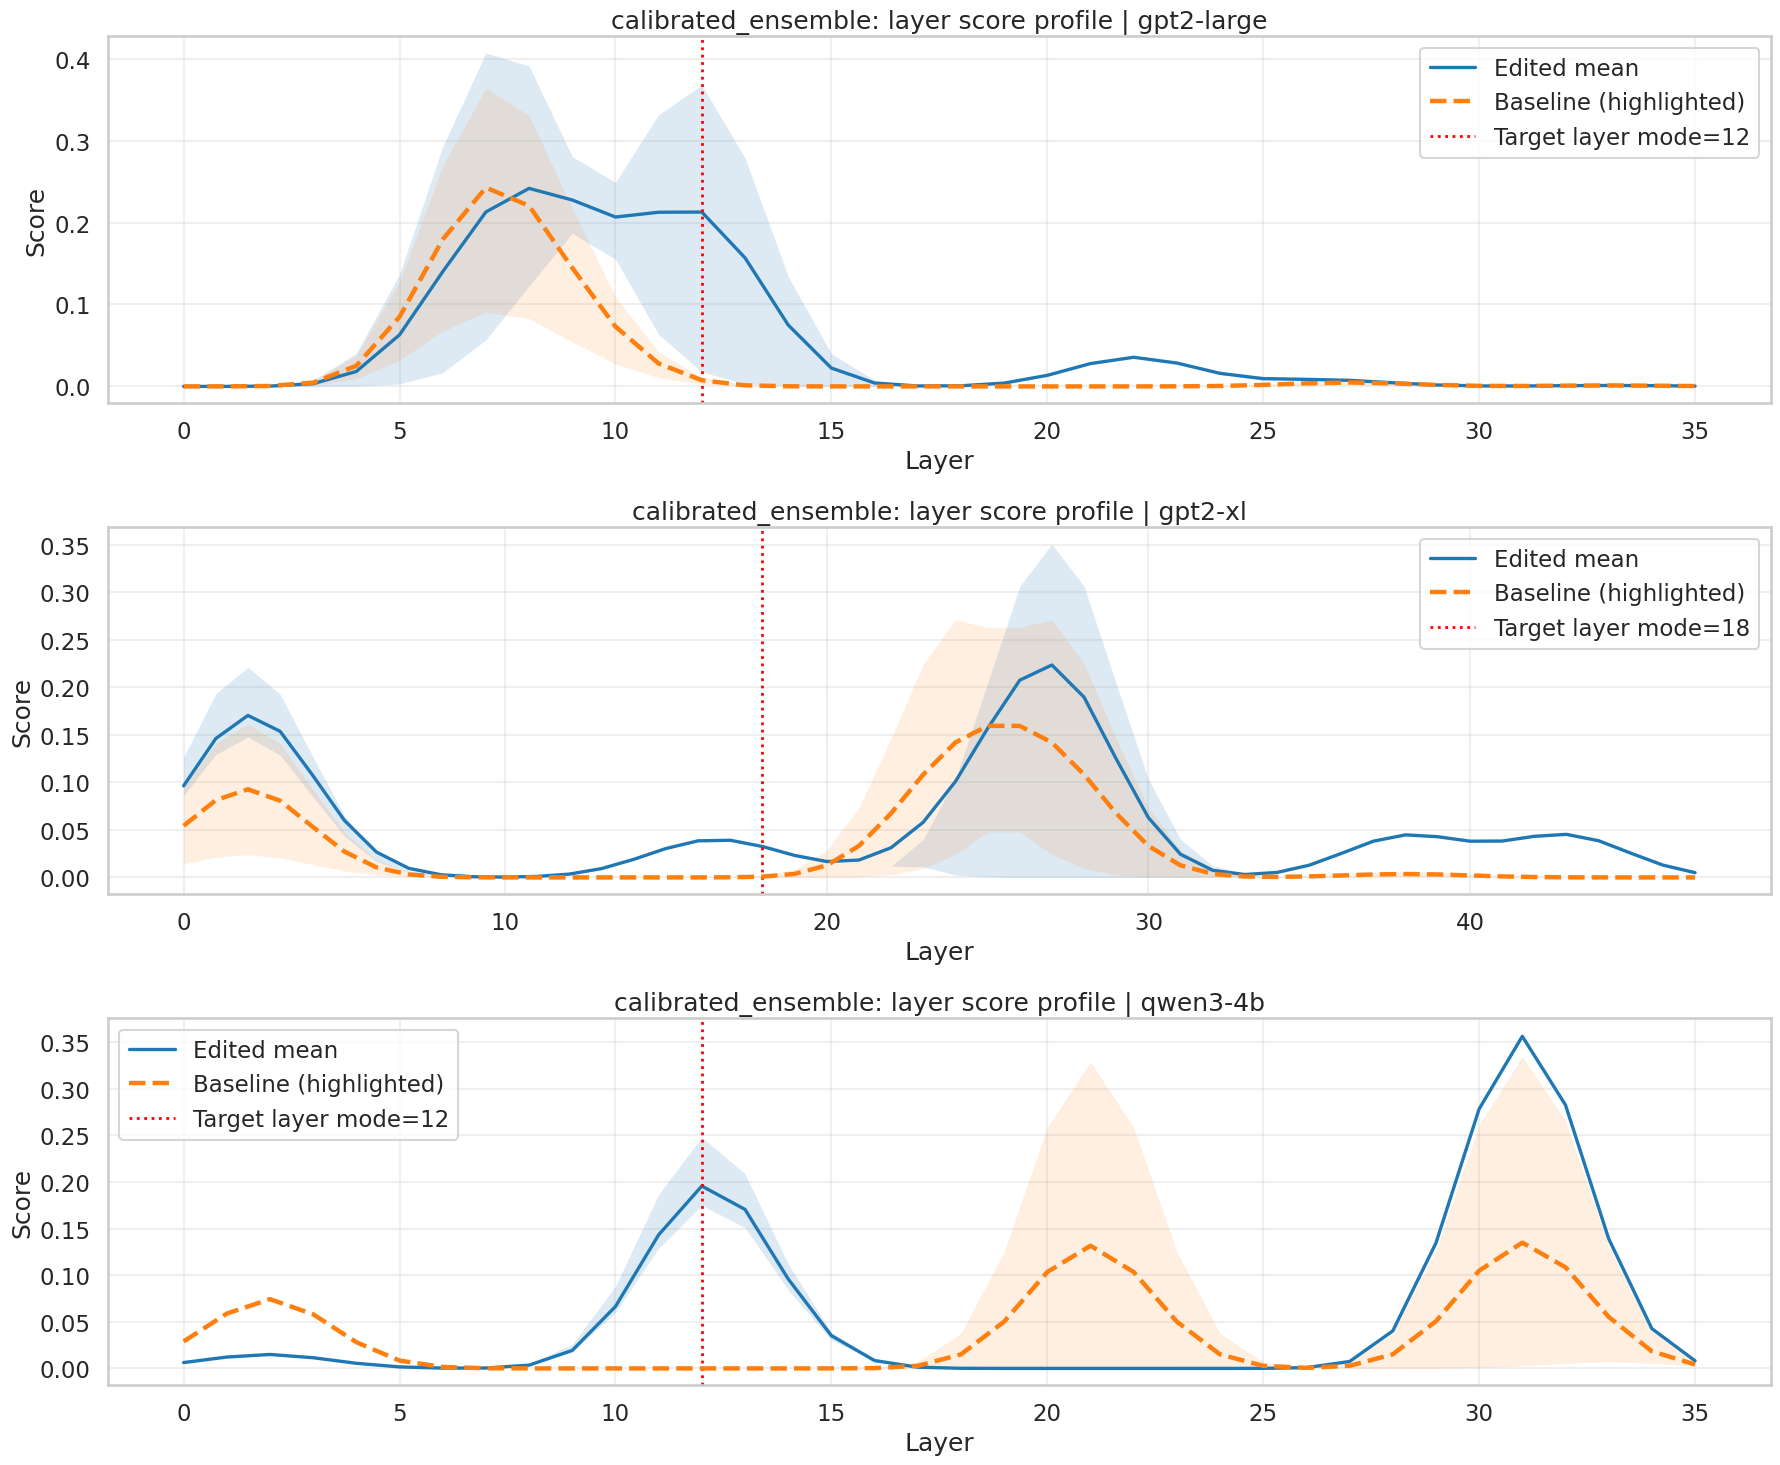

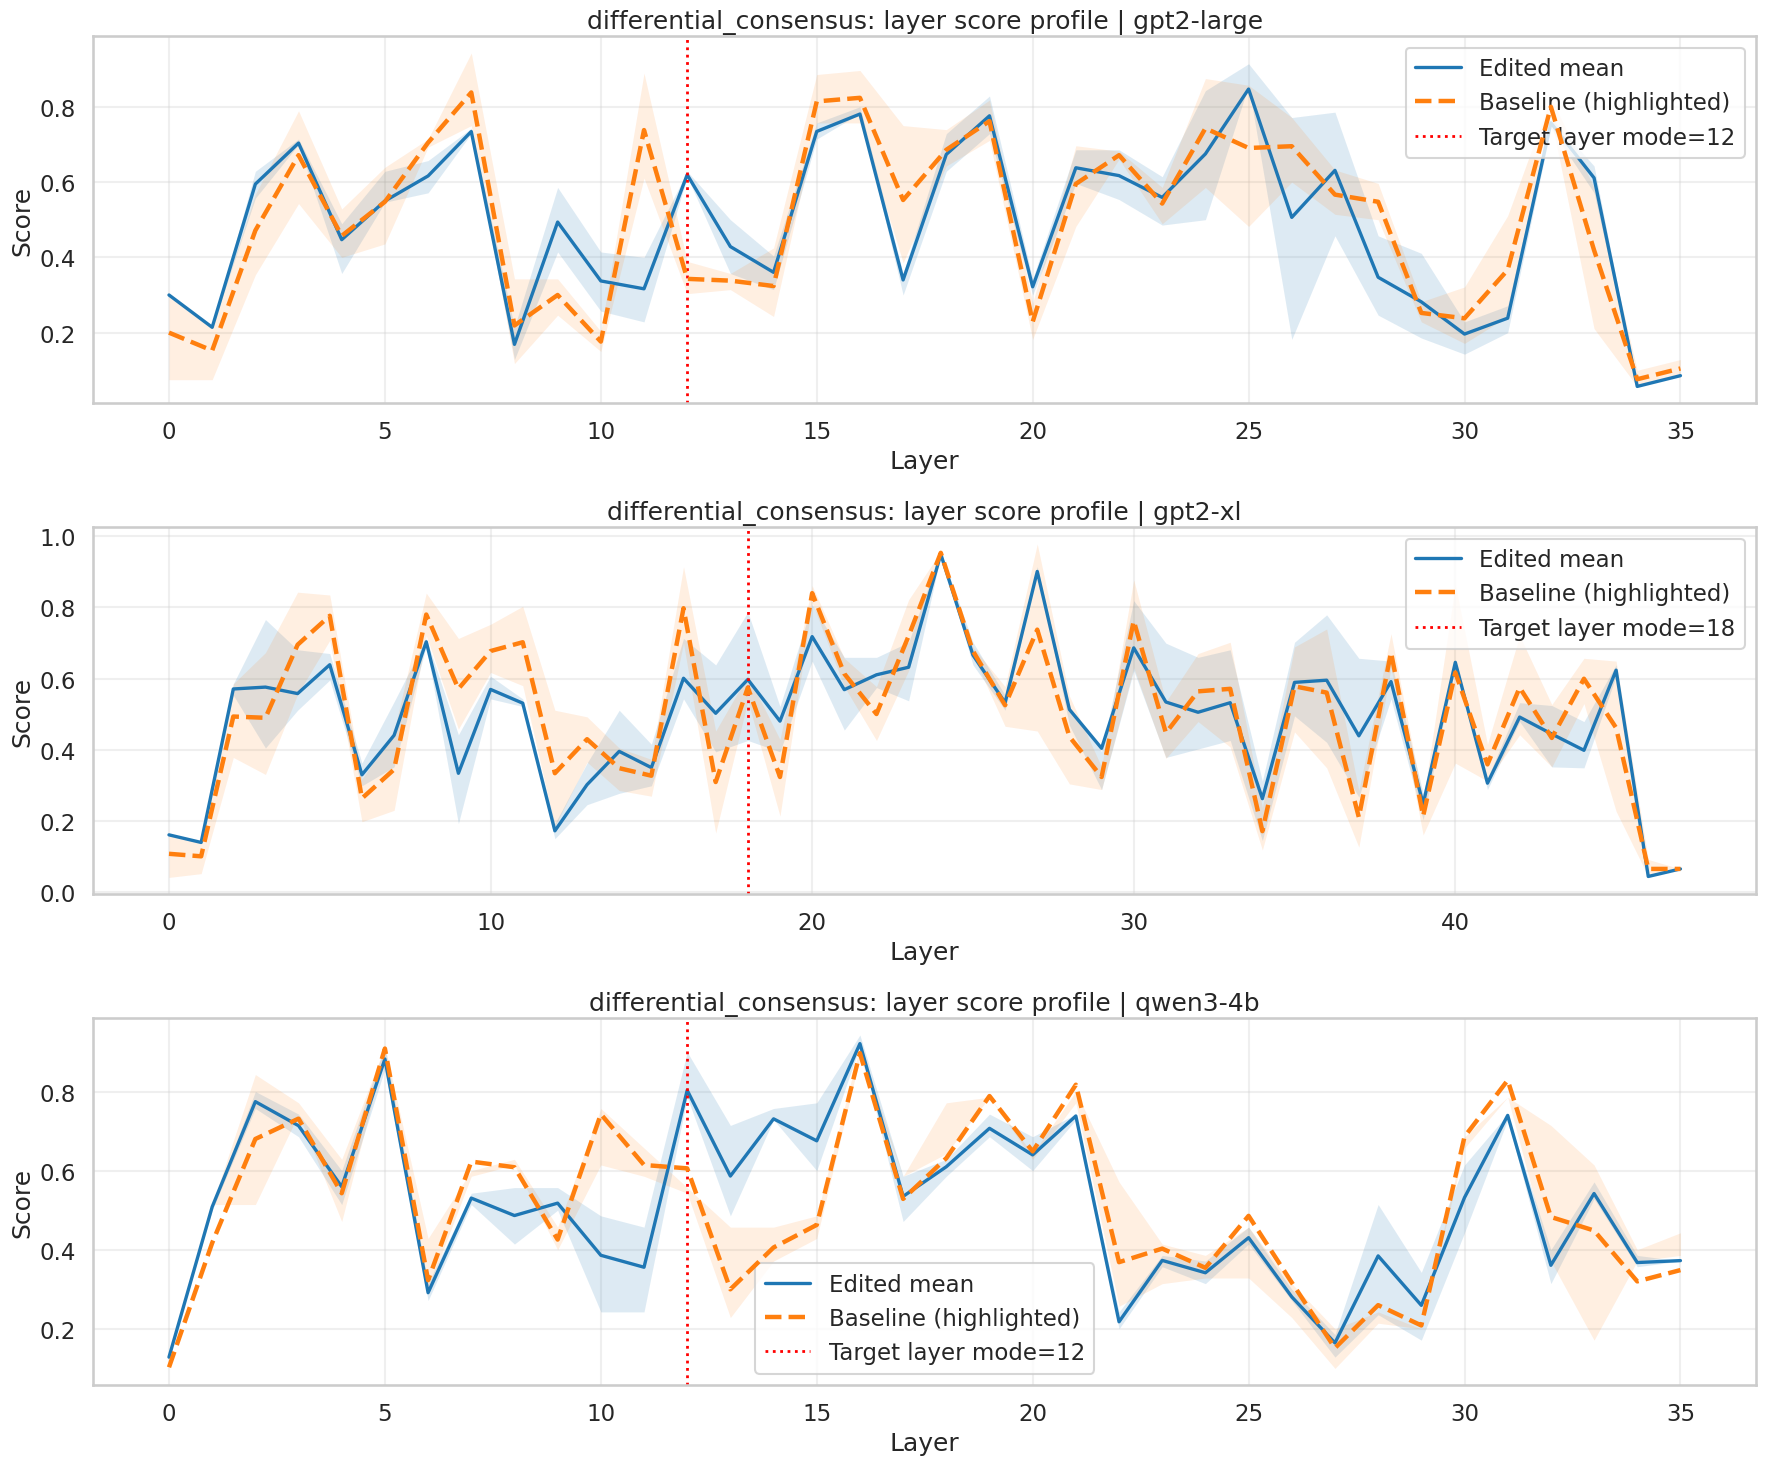

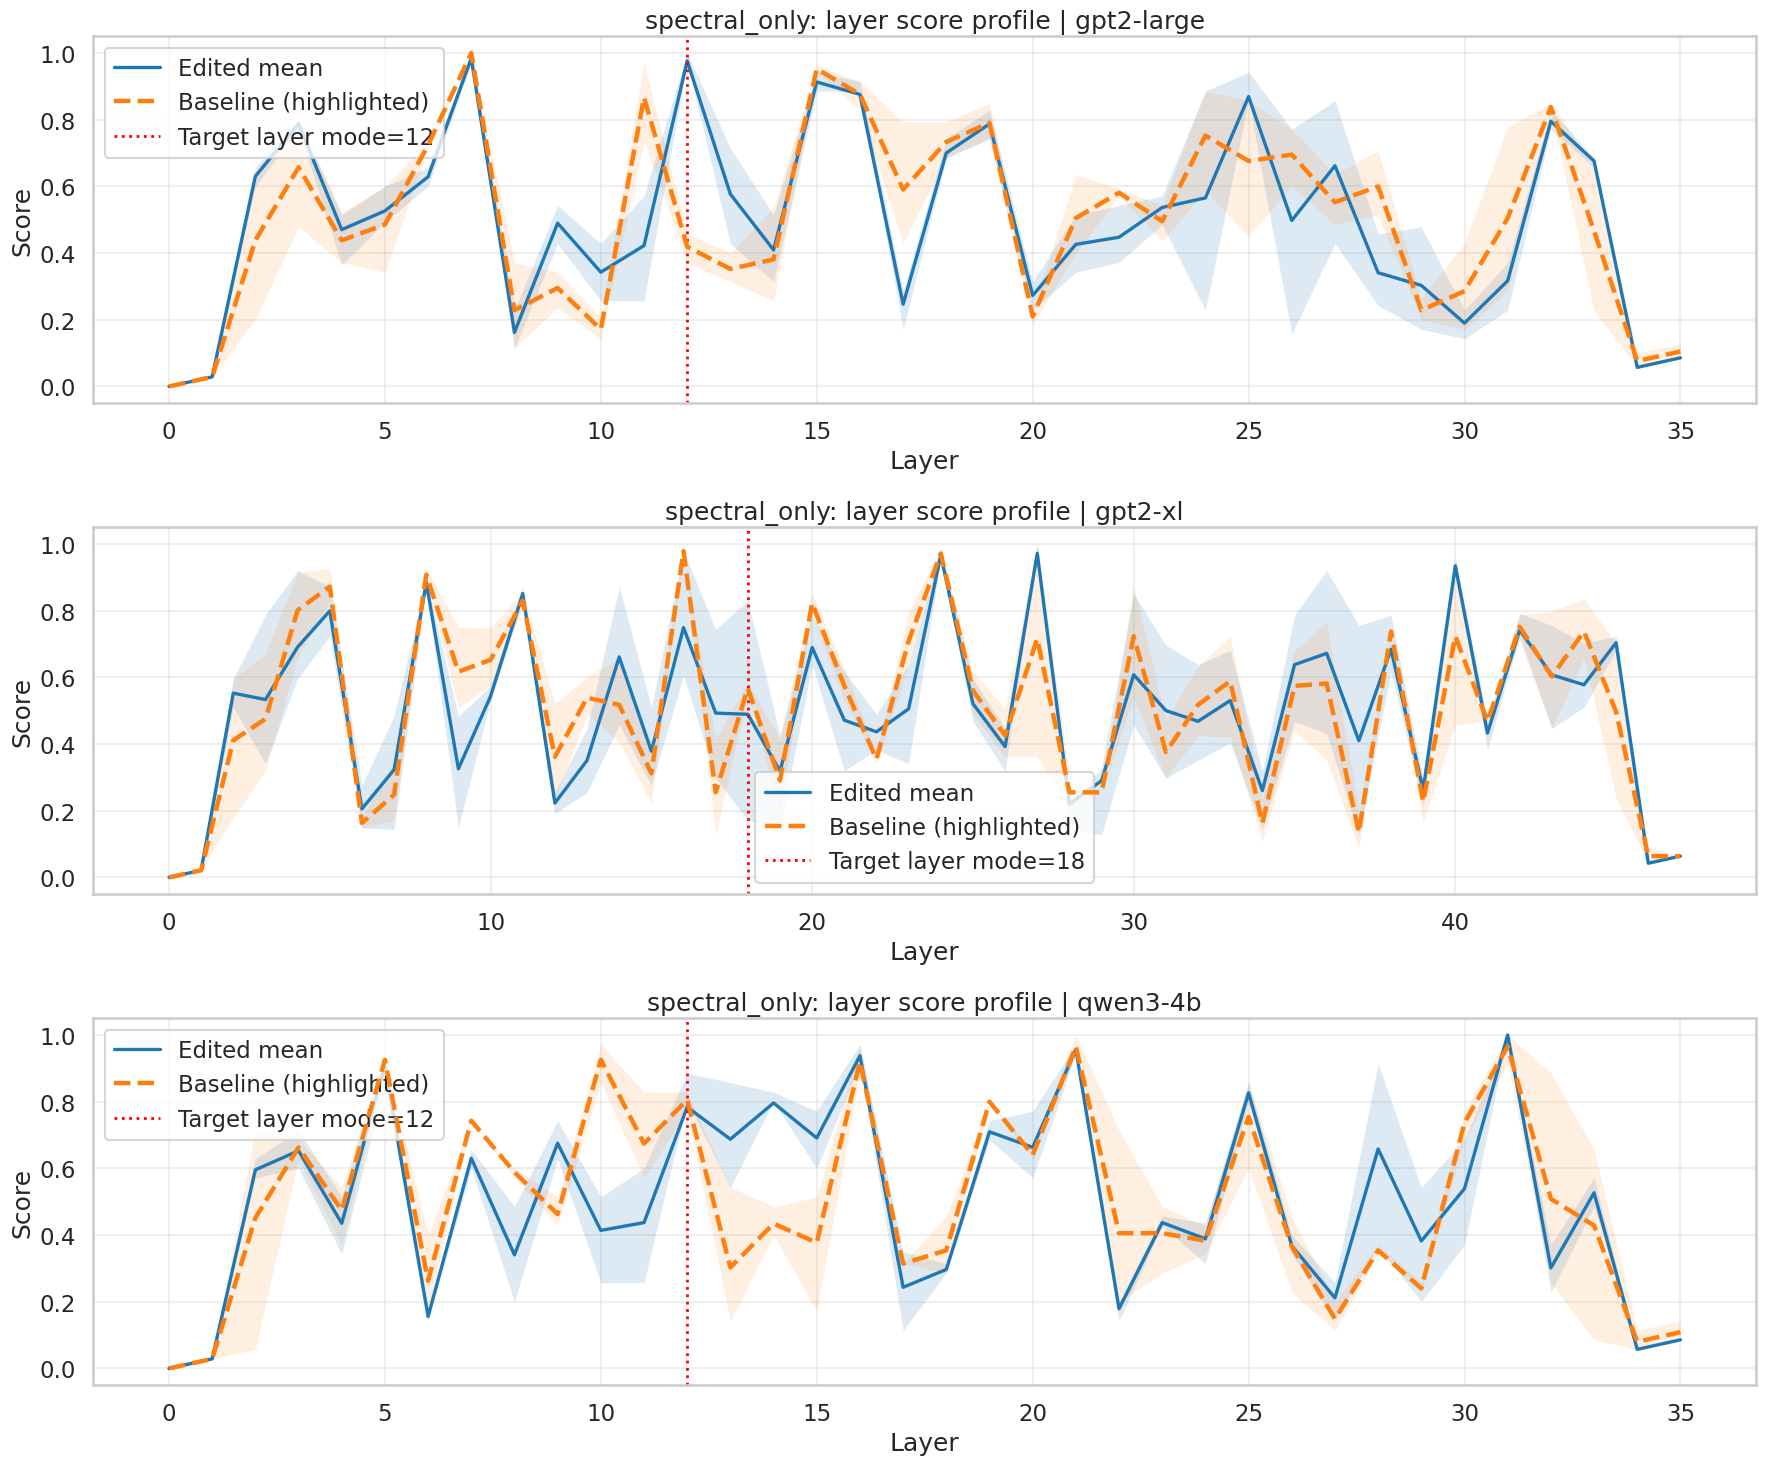

In [35]:
def run_full_outputs_for_strategy(strategy: str) -> pd.DataFrame:
    all_ids = sample_df["sample_id"].tolist()
    return run_strategy(
        strategy=strategy,
        train_ids=all_ids,
        test_ids=all_ids,
        sample_df=sample_df,
        pred_df=pred_df,
        pred_lookup=pred_lookup,
        map_lookup=map_lookup,
    )


def aggregate_layer_curve(outputs_df: pd.DataFrame, model: str, label_edited: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    sub = outputs_df[(outputs_df["model"] == model) & (outputs_df["label_edited"] == label_edited)].copy()
    if sub.empty:
        return np.array([], dtype=int), np.array([], dtype=float), np.array([], dtype=float), np.array([], dtype=float)

    all_layers = sorted({int(k) for d in sub["layer_scores"].tolist() if isinstance(d, dict) for k in d.keys()})
    if not all_layers:
        return np.array([], dtype=int), np.array([], dtype=float), np.array([], dtype=float), np.array([], dtype=float)

    mat = []
    for d in sub["layer_scores"].tolist():
        if not isinstance(d, dict):
            continue
        row = [float(d.get(int(l), d.get(str(l), 0.0))) for l in all_layers]
        mat.append(row)

    if not mat:
        return np.array([], dtype=int), np.array([], dtype=float), np.array([], dtype=float), np.array([], dtype=float)

    arr = np.array(mat, dtype=float)
    mean = np.nanmean(arr, axis=0)
    q25 = np.nanquantile(arr, 0.25, axis=0)
    q75 = np.nanquantile(arr, 0.75, axis=0)
    return np.array(all_layers, dtype=int), mean, q25, q75


full_outputs_by_strategy = {s: run_full_outputs_for_strategy(s) for s in TOP3_STRATEGIES}

for strategy in TOP3_STRATEGIES:
    out_df = full_outputs_by_strategy[strategy]
    models = sorted(out_df["model"].dropna().unique())
    if not models:
        continue

    fig, axes = plt.subplots(len(models), 1, figsize=(18, 5 * len(models)), sharex=False)
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        x_e, y_e, y_e_lo, y_e_hi = aggregate_layer_curve(out_df, model=model, label_edited=1)
        x_b, y_b, y_b_lo, y_b_hi = aggregate_layer_curve(out_df, model=model, label_edited=0)

        if x_e.size:
            ax.plot(x_e, y_e, color="tab:blue", linewidth=2.4, label="Edited mean")
            ax.fill_between(x_e, y_e_lo, y_e_hi, color="tab:blue", alpha=0.15, linewidth=0)

        if x_b.size:
            ax.plot(
                x_b,
                y_b,
                color="tab:orange",
                linestyle="--",
                linewidth=3.2,
                label="Baseline (highlighted)",
                zorder=10,
            )
            ax.fill_between(x_b, y_b_lo, y_b_hi, color="tab:orange", alpha=0.12, linewidth=0)

        model_targets = sample_df[(sample_df["model"] == model) & (sample_df["label_edited"] == 1)]["target_layer"].dropna()
        if not model_targets.empty:
            target_mode = int(model_targets.mode().iloc[0])
            ax.axvline(target_mode, color="red", linestyle=":", linewidth=2.0, label=f"Target layer mode={target_mode}")

        ax.set_title(f"{strategy}: layer score profile | {model}")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Score")
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

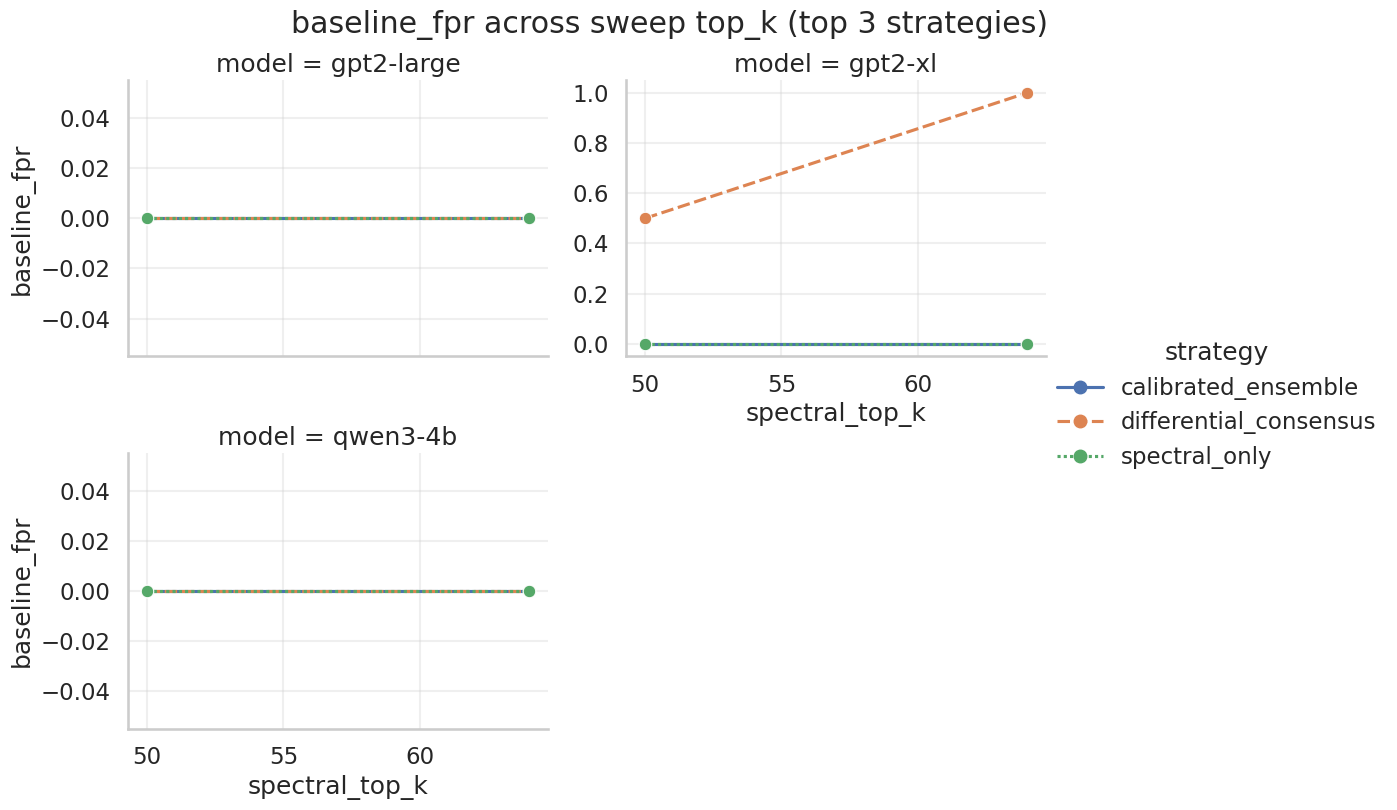

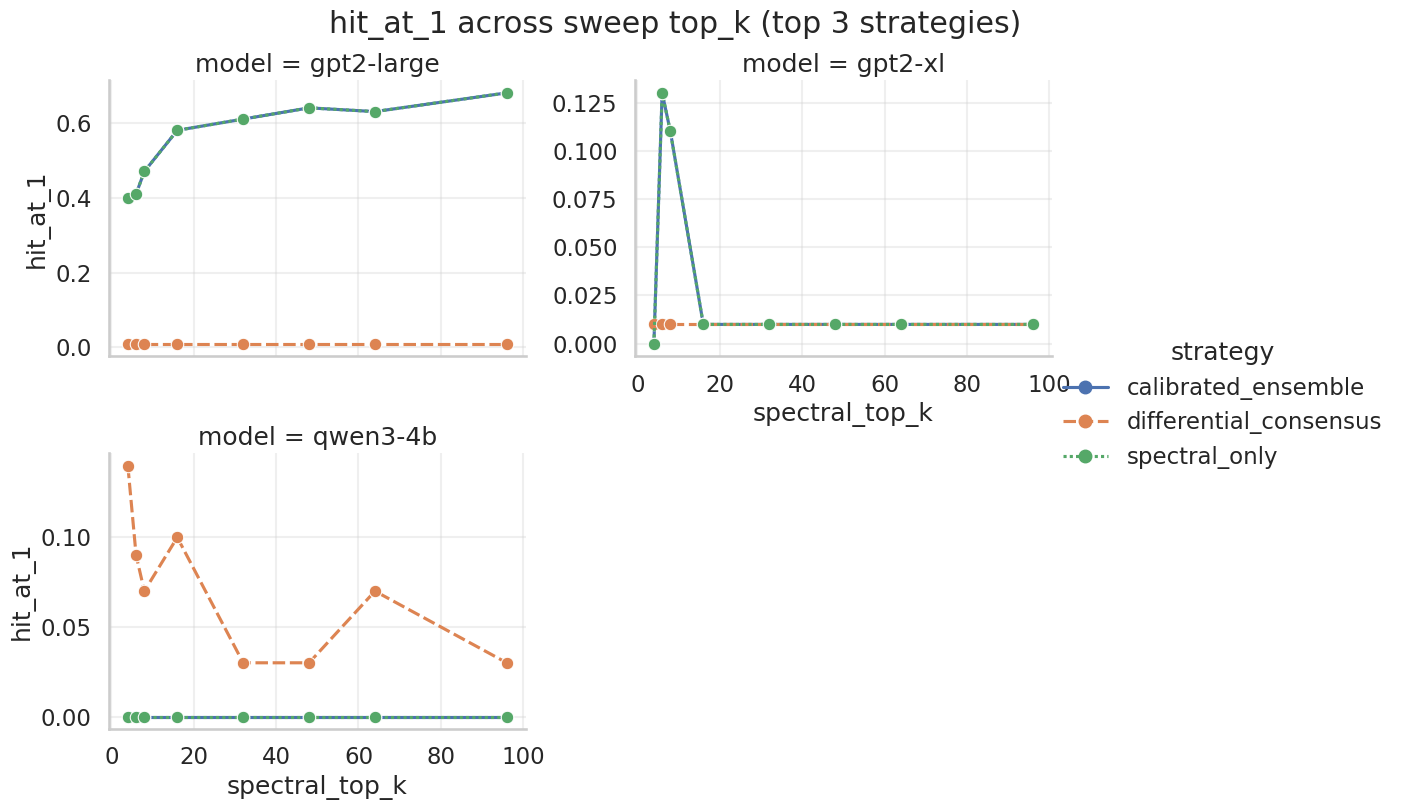

,strategy,metric,model,spectral_top_k,value,n
0,calibrated_ensemble,baseline_fpr,gpt2-large,50,0.00,4
1,calibrated_ensemble,baseline_fpr,gpt2-large,64,0.00,2
2,calibrated_ensemble,baseline_fpr,gpt2-xl,50,0.00,4
3,calibrated_ensemble,baseline_fpr,gpt2-xl,64,0.00,2
4,calibrated_ensemble,baseline_fpr,qwen3-4b,50,0.00,3
5,calibrated_ensemble,baseline_fpr,qwen3-4b,64,0.00,2
6,calibrated_ensemble,hit_at_1,gpt2-large,4,0.40,100
7,calibrated_ensemble,hit_at_1,gpt2-large,6,0.41,100
8,calibrated_ensemble,hit_at_1,gpt2-large,8,0.47,100
9,calibrated_ensemble,hit_at_1,gpt2-large,16,0.58,100


In [36]:
robustness_rows: List[Dict[str, Any]] = []

for strategy in TOP3_STRATEGIES:
    out_df = full_outputs_by_strategy[strategy].merge(
        sample_df[["sample_id", "spectral_top_k", "model", "label_edited", "target_layer"]],
        on=["sample_id", "model", "label_edited", "target_layer"],
        how="left",
        suffixes=("", "_meta"),
    )

    predict_prob, threshold = fit_binary_calibrator(out_df)
    out_df = out_df.copy()
    out_df["p_edited"] = predict_prob(out_df)
    out_df["pred_edited"] = (out_df["p_edited"] >= threshold).astype(int)

    # Baseline false-positive vs top_k
    base = out_df[out_df["label_edited"] == 0].copy()
    if not base.empty:
        fpr_by_topk = (
            base.groupby(["model", "spectral_top_k"], as_index=False)
            .agg(baseline_fpr=("pred_edited", "mean"), n=("sample_id", "nunique"))
        )
        for r in fpr_by_topk.itertuples(index=False):
            robustness_rows.append({
                "strategy": strategy,
                "metric": "baseline_fpr",
                "model": r.model,
                "spectral_top_k": r.spectral_top_k,
                "value": r.baseline_fpr,
                "n": r.n,
            })

    # Localization hit@1 vs top_k
    edited = out_df[(out_df["label_edited"] == 1) & out_df["pred_layer"].notna() & out_df["target_layer"].notna()].copy()
    if not edited.empty:
        edited["abs_err"] = (edited["pred_layer"] - edited["target_layer"]).abs()
        h1_by_topk = (
            edited.groupby(["model", "spectral_top_k"], as_index=False)
            .agg(hit_at_1=("abs_err", lambda s: float((s <= 1).mean())), n=("sample_id", "nunique"))
        )
        for r in h1_by_topk.itertuples(index=False):
            robustness_rows.append({
                "strategy": strategy,
                "metric": "hit_at_1",
                "model": r.model,
                "spectral_top_k": r.spectral_top_k,
                "value": r.hit_at_1,
                "n": r.n,
            })

robustness_df = pd.DataFrame(robustness_rows)

if not robustness_df.empty:
    for metric in ["baseline_fpr", "hit_at_1"]:
        plot_df = robustness_df[robustness_df["metric"] == metric].copy()
        if plot_df.empty:
            continue

        g = sns.relplot(
            data=plot_df,
            x="spectral_top_k",
            y="value",
            hue="strategy",
            style="strategy",
            kind="line",
            col="model",
            marker="o",
            col_wrap=2,
            facet_kws={"sharey": False, "sharex": True},
            height=4,
            aspect=1.4,
        )
        g.set_axis_labels("spectral_top_k", metric)
        g.fig.suptitle(f"{metric} across sweep top_k (top 3 strategies)", y=1.02)
        plt.show()

display(robustness_df.head(30))

## Final Top-3 Recommendation

This section summarizes the best three approaches selected from protocol-averaged rank performance.

Interpretation guide:

- Higher is better: exact, hit_at_1, hit_at_2, roc_auc, pr_auc, edited_tpr.
- Lower is better: baseline_fpr, mae.
- The recommended default is the top strategy by lowest overall rank_score.


In [ ]:
top3_report = TOP3.copy()
if not top3_report.empty:
    top3_report = top3_report[[
        "strategy",
        "rank_score",
        "exact",
        "hit_at_1",
        "hit_at_2",
        "baseline_fpr",
        "mae",
        "roc_auc",
        "pr_auc",
    ]]

print("Selected top 3 strategies")
display(top3_report)

if not top3_report.empty:
    default_strategy = str(top3_report.iloc[0]["strategy"])
    print(f"Recommended default strategy: {default_strategy}")

artifact_dir = ROOT / "analysis_out" / "complex_analysis" / "final_blind_detection_artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

summary_by_protocol.to_csv(artifact_dir / "summary_by_protocol.csv", index=False)
summary_overall.to_csv(artifact_dir / "summary_overall.csv", index=False)
TOP3.to_csv(artifact_dir / "top3_strategies.csv", index=False)
metrics_df.to_csv(artifact_dir / "fold_metrics.csv", index=False)
predictions_df.to_csv(artifact_dir / "fold_predictions.csv", index=False)
robustness_df.to_csv(artifact_dir / "robustness_by_topk.csv", index=False)

print(f"Saved artifacts to: {artifact_dir}")

Selected top 3 strategies


,strategy,rank_score,exact,hit_at_1,hit_at_2,baseline_fpr,mae,roc_auc,pr_auc
0,calibrated_ensemble,1.333333,0.130139,0.352361,0.361806,0.000000,8.659444,1.000000,1.000000
1,differential_consensus,2.666667,0.030000,0.030000,0.030000,0.370370,7.804167,0.682278,0.996164
2,spectral_only,2.833333,0.196250,0.196250,0.224583,0.111111,10.396667,0.497824,0.993818


Recommended default strategy: calibrated_ensemble
Saved artifacts to: /data/olexa/Latium/analysis_out/complex_analysis/final_blind_detection_artifacts
